[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KalininGroup/camm_hackathon/blob/k4my4r/docs/day_5_11212025/2025_Ferrosim_CAMM_hackaton.ipynb)


# **FerroSim: Kinetic Lattice Ferroelectric Model**

**Author: Rama Vasudevan**

This simulator evolves a ferroelectric polarization field using a time-dependent Ginzburg–Landau (TDGL) model on a 2D lattice. Each site carries a polarization order parameter:

- **Uniaxial:** scalar $p_{ij}$
- **Squareelectric:** two uncoupled components $(p_{x,ij},p_{y,ij})$
- **Tetragonal / Rhombohedral:** coupled vector $(p_{x,ij},p_{y,ij})$

The total free energy is:
$$
F = F_{\text{Landau}} + F_{\text{coupl}} + F_{\text{field}}
$$

### **1. Landau Free Energy (local double-well / multi-well potential)**

- **Uniaxial / Squareelectric:**
  $$
  F_L = \frac{\alpha_1}{2}p^2 + \frac{\alpha_2}{4}p^4
  $$
- **Tetragonal / Rhombohedral:**
  $$
  F_L = \alpha_1 (p_x^2+p_y^2)
       + \alpha_2 (p_x^4+p_y^4)
       + \alpha_3 p_x^2 p_y^2
  $$

### **2. Couping Energy**

$$
F_{\text{coupl}} = K \sum_{k,l} (p_{ij} - p_{i+k,j+l})^2
$$


### **3. Electric Field Terms**

Local field:
$$
E_{\text{loc}} = E_{\text{ext}} + E_{\text{dep}} + E_d(i,j)
$$

Depolarization field:
$$
E_{\text{dep}} = -\alpha_{\text{dep}} \langle P \rangle
\qquad
\langle P \rangle = \frac{1}{N^2}\sum_{ij} p_{ij}
$$

External field $E_{\text{ext}}(t)$ can be an arbitrary waveform.

Defect field $E_d(i,j)$ introduces random-field.

### **4. TDGL Dynamics**

Evolution follows:
$$
\frac{dp_{ij}}{dt} = -\gamma \frac{\partial F}{\partial p_{ij}}
$$

Updated explicitly:
$$
p_{ij}(t+\Delta t) = p_{ij}(t) + \Delta t\,\frac{dp_{ij}}{dt}
$$

$\gamma$ is the mobility (domain-wall damping).  
$\Delta t$ is the numerical time step.

### **5. Model Parameters**

- **Landau coefficients:** $\alpha_1, \alpha_2, \alpha_3$
- **Coupling:** $K$
- **Depolarizing coef.:** $\alpha_{\text{dep}}$
- **External field:** $E_{\text{ext}}(t)$
- **Defect field:** $E_d(i,j)$
- **Mobility:** $\gamma$
- **Time step:** $\Delta t$

### **Modes Summary**

- **Uniaxial:** scalar double-well potential.
- **Squareelectric:** two independent double wells in $x$ and $y$.
- **Tetragonal:** coupled components; minima along axes.
- **Rhombohedral:** coupled components; minima along diagonal directions.

This toy model captures ferroelectric switching, domain formation, domain wall motion, defect pinning, and polarization dynamics under applied fields.


**Default coef.** **$\alpha_1$ $\alpha_2$ $\alpha_3$**

*Uniaxial:* -1.85,	1.25, N/A

*Squareelectric:* -1.85,	1.25, N/A

*Tetragonal:* -1.6	12.2	40.0

*Rhombohedral:* -10.6	10.2	-10.0

**NOTE: The coefficients for the rhomohedral case don't appear to be very good. Need to adjust them.**





---






**Github**: https://github.com/ramav87/FerroSim/tree/rama-dev (branch: rama-dev)

In [ ]:
# !pip install -e git+https://github.com/ramav87/FerroSim.git@rama-dev#egg=FerroSim



> **Session must be restarted after ferrosim lib uploading**



In [ ]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import gridspec

import h5py
import math

from typing import Dict
from itertools import product

from ferrosim import Ferro2DSim

## Uniaxial switching

In [ ]:
Pmats = []
for temp in [300, 350, 410, 420]:
  time_vec = np.linspace(0,2,500)

  #Let's now make a somewhat complicated electric field
  Evec_x = 0*np.ones(len(time_vec))
  Evec_y = 190*np.sin(2*np.pi*time_vec)
  applied_field = np.vstack((Evec_x, Evec_y)).T

  landau_parms = {'alpha1': 1.85/100 , 'alpha2':1.25 } #alpha1 is technically the temperature independent term, it gets multiplied by T diff.

  init_pmat = np.random.uniform(low = -0.2, high = 0.2, size = (10,10))*1.0E-6
  init_pmat_full = np.zeros(shape=(10,10,2))
  init_pmat_full[:,:,1] = init_pmat


  sim = Ferro2DSim(mode = 'uniaxial',
                   k = 1.0,
                   temp = temp,
                   time_vec = time_vec,
                   appliedE = applied_field,
                   initial_p = init_pmat_full,
                   landau_parms = landau_parms,
                   )
  sim.runSim()

  sim.plot_summary()
  #sim.plot_quiver()
  Pmats.append(sim.getPmat())
  del sim

In [ ]:
plt.figure()
labels = ['300K', '350K', '410K', '420K']
for ind in range(4):
  fe_loop = Pmats[ind][1,:,:,:].sum(axis=((-1,-2)))
  plt.plot(applied_field[250:,1], fe_loop[250:], label = labels[ind])
plt.legend(loc = [1.05, 0.65], fontsize = 14)

plt.xlabel('Field (a.u.)', fontsize = 14)
plt.ylabel('Polarization (a.u.)', fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

## Custom field: tetragonal

In [ ]:
time_vec = np.linspace(0,2,500)

#Let's now make a somewhat complicated electric field
Evec_x = 180*((time_vec+0.5)**2)*np.sin(2*np.pi*time_vec)
Evec_y = 180*((time_vec+0.5)**2)*np.cos(4*np.pi*time_vec)

applied_field = np.vstack((Evec_x, Evec_y)).T

#Let's plot this to see what it looks like
fig, axes = plt.subplots()
axes.plot(time_vec, applied_field[:,0], label ='$E_x$')
axes.plot(time_vec, applied_field[:,1], label ='$E_y$')
axes.set_xlabel('Time (a.u.)', fontsize = 18)
axes.set_ylabel('$E/E_C$', fontsize = 18)
fig.legend(loc = [0.25, 0.70], fontsize = 14)

In [ ]:
sim = Ferro2DSim(n=20, time_vec = time_vec, appliedE= applied_field,
                 mode = 'tetragonal', init = 'random')
sim.runSim()
sim.plot_quiver()
sim.plot_summary()

## Adding Custom Defects

We can also add defects to the simulation easily.

### Random Field Effects
Defects can interact with the lattice through field effects (no elastic considerations in this model whatsoever). The simulation expects defects to be entered in as a list of length (n x n) with each element being a tuple $(RF_x, RF_y)$. The units of the $RF_x$ and $RF_y$ are, as with the applied field, multiples of the nominal coercive field (set by the simulations alpha and beta values in the Landau expansion - that can also be changed if you so wish!).

### Random Bond Effects
We can also add defects that produce random-bond disorder: in this case, the coupling constant k is no longer uniform, but spatially dependent. So, k should now be provided as a list of size (n x n). The Default is a list of length (n x n) with all elements set to 1.0.

### Screening effects
Finally, we note that depolarization effects are considered in the model as a uniform constant multipled by the total polarization. However, we can alter this by assuming some screening (e.g., from migration of internal charges, or band bending etc.). The simulation then expects a list of length (n x n) with each element equal to the factor that multiples the total polarization. The Default is set to 0.0 at all sites.

In [ ]:
n = 20 #lattice size
time_vec = np.linspace(0,4,500)

defect_list = []
for row in range(n):
    for col in range(n):
        Efx = 0.01
        Efy = 0.01
        #We place defects every fifth row and 2nd column
        if row%5==0 and col%10==0: Efy = np.random.normal(loc = 15.5, scale = 0.1)

        defect_list.append((Efx, Efy))
defect_list = np.array(defect_list)


#Let's add some random bond disorder. Here we will assume the random bond disorder
#is just a small noise term on teh existing constant value
k = [np.random.normal(loc=1.0,scale = 0.1) for ind in range(n*n)]

#Finally, let's also play with the depolarization. In this case it is going to be random.
dep_alpha = [np.random.uniform(low=0.4, high= 0.8) for ind in range(n*n)]

#Let's just have a sinusoidal field
Evec_x = 10*np.ones(len(time_vec))
Evec_y = 190*np.sin(2*np.pi*time_vec)
applied_field = np.vstack((Evec_x, Evec_y)).T

In [ ]:
sim = Ferro2DSim(n=n,
                 time_vec = time_vec,
                 appliedE=applied_field,
                 defects=defect_list,
                 k=k,
                 dep_alpha = dep_alpha,
                 mode = 'tetragonal')

In [ ]:
sim.runSim()
sim.plot_summary()

## "Domain" structures

In [ ]:
def ferrosim_calc1(patch,
                  gamma = 30,
                  defect_field = (30,.01),
                  c_const = 1.1,
                  Eamp = (0, 2),
                  time_vec_length = 3000,
                  dep_alpha = 1E-9):
  #tiem vec
  time_vec = np.linspace(0,2,time_vec_length)
  flat_patch = np.array(patch.flatten())

  #defect field
  Efx, Efy = defect_field

  defect_list = np.zeros((len(flat_patch),2))#np.ones((len(flat_patch),2))*1E-6
  defect_list[flat_patch==0] = (Efx, 0)
  defect_list[flat_patch!=0] =  np.array([np.zeros(len(flat_patch[flat_patch!=0])), -flat_patch[flat_patch!=0]*Efy]).T

  #coupling constant
  k = np.zeros(len(flat_patch))
  k[flat_patch!=0] = c_const

  #applied field
  Evec_x = Eamp[0]*np.ones(len(time_vec))
  Evec_y = Eamp[1]*np.sin(2*np.pi*time_vec)
  applied_field = np.vstack((Evec_x, Evec_y)).T

  #initial P
  init_p  = np.zeros((ws,ws,2))#np.random.uniform(low = -0.2, high = 0.2, size = (ws,ws,2))*1.0E-9

  init_p[:,:,0][patch==0] = 1
  init_p[:,:,1][patch!=0] = patch[patch!=0]*.5

  sim = Ferro2DSim(n=ws,
                  time_vec = time_vec,
                  appliedE=applied_field,
                  defects=defect_list,
                  k=k,
                  dep_alpha = dep_alpha,
                  mode = 'tetragonal',
                  gamma=gamma,
                  initial_p = init_p,)

  sim.runSim();

  return (applied_field.T, sim.results['Polarization'])


def res_pattern(k, stripe_frequency, phase, size=(12,12)):
  c_domain_pattern = c_domain(k, size=size)
  a_domain_pattern = striped_pattern(stripe_frequency, phase, size=size)
  res = (c_domain_pattern*2-1) * (~a_domain_pattern)
  return res, c_domain_pattern, a_domain_pattern

def c_domain(k, size=(12,12)):
  a_pattern = np.array([[1 if (i-k < j) else 0 for j in range(size[0])] for i in range(size[1])])
  return a_pattern.astype(bool)

def striped_pattern(stripe_frequency, phase, size=(12,12), stripe_width=2):
  pattern = np.zeros(size, dtype=int)

  for i in range(size[0]):
      for j in range(size[1]):
          if ((i + j) // stripe_width + phase) % stripe_frequency == 0:
              pattern[i, j] = 1

  return pattern.astype(bool)

def shoelace_formula(x, y):
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

In [ ]:
ws = 15

sf = np.arange(1,9)

patterns = []
for f in sf:
  patterns.append(res_pattern(-15, f, 1, size=(ws,ws)))


fig, ax = plt.subplots(1, len(patterns), figsize=(len(patterns), 1.2), dpi=200)

for i,p in enumerate(patterns):
  ax[i].imshow(p[0], vmin=-1, vmax=1, cmap='coolwarm')
  ax[i].tick_params(labelleft=False, labelbottom=False)
  ax[i].set_title(f"period= {sf[i]}", fontsize=9)

In [ ]:
pol_ar = []

for i,p in enumerate(patterns):
  v, pol = ferrosim_calc1(p[0],
                  gamma = 30, #kinetic coefficient in Landau-Khalatnikov equation (~wall mobility)
                  defect_field = (30,.1),
                  c_const = 0, #coupling constant
                  Eamp = (0, 2), #amplitude of the applied voltage
                  time_vec_length = 2000, #number of the time steps, we always apply 2 sin period
                  dep_alpha = .3 #depolarization constant
                          )
  pol_ar.append(pol)

pol_ar = np.array(pol_ar) #polarization hysteresis loops

In [ ]:
loop_area = np.array([])
fig, ax = plt.subplots(1,2, figsize=(7,3))

for pp in pol_ar:
  loop_area = np.append(loop_area, float(shoelace_formula(v[1,-1000:], pp[1, -1000:]))) #
  ax[0].plot(v[1], pp[1])

ax[0].grid()
ax[0].set_ylabel("Polarization")
ax[0].set_xlabel("Field")
ax[0].set_ylim(-80,80)

ax[1].plot(sf, loop_area)
ax[1].grid()
ax[1].set_ylabel('Area')
ax[1].set_xlabel('Period of stripes')

plt.tight_layout()

Kamyar _

In [ ]:
def loop_features(E, P, zero_window=0.05):

    # Sort by E in case loop isn't monotonic
    sort_idx = np.argsort(E)
    E = E[sort_idx]
    P = P[sort_idx]

    feats = {}

    # ------------------------------------
    # Loop area (shoelace / polygon area)
    # ------------------------------------
    area = 0.5 * np.abs(np.dot(E, np.roll(P, 1)) - np.dot(P, np.roll(E, 1)))
    feats["loop_area"] = float(area)

    # ------------------------------------
    # Remanent Polarization Pr±
    # Find P(E=0) by linear interpolation
    # ------------------------------------
    # indices near zero crossing
    zero_idx = np.argmin(np.abs(E))
    feats["Pr"] = float(P[zero_idx])

    # More robust interpolation:
    if np.any(np.diff(np.sign(P)) != 0):
        # polarity flips: separate branches
        # split E,P into below and above zero-field
        left_mask  = E < 0
        right_mask = E > 0

        # remanent from left approach
        if np.sum(left_mask) > 1:
            feats["Pr_minus"] = float(np.interp(0, E[left_mask], P[left_mask]))
        else:
            feats["Pr_minus"] = feats["Pr"]

        # remanent from right approach
        if np.sum(right_mask) > 1:
            feats["Pr_plus"] = float(np.interp(0, E[right_mask], P[right_mask]))
        else:
            feats["Pr_plus"] = feats["Pr"]

    else:
        # if curve does not cross, fallback
        feats["Pr_minus"] = feats["Pr"]
        feats["Pr_plus"]  = feats["Pr"]

    # ------------------------------------
    # Coercive field Ec± where P crosses zero
    # Need to find E where P = 0
    # ------------------------------------
    # Indices where P changes sign
    crossings = np.where(np.diff(np.sign(P)) != 0)[0]
    if len(crossings) >= 2:
        # first crossing → negative coercive, second → positive coercive
        c1 = crossings[0]
        c2 = crossings[-1]
        Ec_minus = np.interp(0, [P[c1], P[c1+1]], [E[c1], E[c1+1]])
        Ec_plus  = np.interp(0, [P[c2], P[c2+1]], [E[c2], E[c2+1]])
    else:
        Ec_minus = np.nan
        Ec_plus  = np.nan

    feats["Ec_minus"] = float(Ec_minus)
    feats["Ec_plus"]  = float(Ec_plus)

    # ------------------------------------
    # Slope near origin
    # local slope = dP/dE at E=0
    # ------------------------------------
    E_range = E.max() - E.min()
    window = zero_window * E_range
    mask = np.abs(E) < window

    if np.sum(mask) > 3:
        # Linear least squares fit: P = a*E + b
        a, b = np.polyfit(E[mask], P[mask], 1)
        feats["slope_at_origin"] = float(a)
    else:
        feats["slope_at_origin"] = np.nan

    return feats


In [ ]:
E = applied_field[250:,1]
P = fe_loop[250:]

features = loop_features(E, P)
print(features)

| Index | Feature                         | Meaning                     |
|-------|----------------------------------|-----------------------------|
| 0     | $E_c^{-}$                        | Negative switching field    |
| 1     | $E_c^{+}$                        | Positive switching field    |
| 2     | $P_r^{-}$                        | Remanent polarization (−)   |
| 3     | $P_r^{+}$                        | Remanent polarization (+)   |
| 4     | $\text{loop\_area}$              | Energy dissipated per cycle |
| 5     | $\left.\dfrac{dP}{dE}\right|_{E=0}$ | Local susceptibility        |


SIM

In [ ]:
import numpy as np
from tqdm import tqdm

# ---------------------------------------
# 2. Simulation wrapper
# ---------------------------------------
def run_uniaxial_sim(temp, alpha1, alpha2):

    time_vec = np.linspace(0, 2, 400)   # faster but still stable

    # field: sin only in y
    Evec_x = np.zeros_like(time_vec)
    Evec_y = 190 * np.sin(2 * np.pi * time_vec)
    applied_field = np.vstack((Evec_x, Evec_y)).T

    landau_parms = {'alpha1': alpha1, 'alpha2': alpha2}

    # use deterministic initial condition (cleaner training signal)
    init_pmat_full = np.zeros((10, 10, 2))

    sim = Ferro2DSim(
        mode='uniaxial',
        k=1.0,
        temp=temp,
        time_vec=time_vec,
        appliedE=applied_field,
        initial_p=init_pmat_full,
        landau_parms=landau_parms,
    )
    sim.runSim()

    Pmat = sim.getPmat()
    fe_loop = Pmat[1, :, :, :].sum(axis=(-1, -2))

    # slice the steady-state part
    cut = int(0.5 * len(time_vec))
    E = applied_field[cut:, 1]
    P = fe_loop[cut:]

    feats = loop_features(E, P)
    del sim
    return feats

# ---------------------------------------
# 3. Generate dataset
# ---------------------------------------
N = 1000
X = []
Y = []
rows = []

alpha1_base = 1.85 / 100
alpha2_base = 1.25

temps = np.random.uniform(280, 450, size=N)

for temp in tqdm(temps):

    # jitter the parameters (30%)
    alpha1 = alpha1_base * np.random.uniform(0.7, 1.3)
    alpha2 = alpha2_base * np.random.uniform(0.7, 1.3)

    feats = run_uniaxial_sim(temp, alpha1, alpha2)

    X.append([temp, alpha1, alpha2])
    Y.append([
        feats['Ec_minus'],
        feats['Ec_plus'],
        feats['Pr_minus'],
        feats['Pr_plus'],
        feats['loop_area'],
        feats['slope_at_origin']
    ])

    rows.append({
        'temp': temp,
        'alpha1': alpha1,
        'alpha2': alpha2,
        **feats
    })

# Convert to numpy
X = np.array(X)
Y = np.array(Y)

print("Dataset shapes:")
print("X:", X.shape)
print("Y:", Y.shape)


Train a regressor

In [ ]:
print("Dataset shapes:")
print("X:", X.shape)
print("Y:", Y.shape)

In [53]:
X = np.array(X) 
print(X.shape)  # shape: (N, 3)
Y = np.array(Y)
print(Y.shape)  

(1000, 3)
(1000, 6)


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0
)


In [55]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=0,
    max_depth=None,
)

model.fit(X_train, Y_train)


RandomForestRegressor(n_estimators=200, random_state=0)

In [56]:
from sklearn.metrics import r2_score, mean_absolute_error
Y_pred = model.predict(X_test)

print("R2 scores per output:", r2_score(Y_test, Y_pred, multioutput='raw_values'))
print("MAE per output:", mean_absolute_error(Y_test, Y_pred, multioutput='raw_values'))

R2 scores per output: [0.98921352 0.98605117 0.9976501  0.9979228  0.9880104  0.99622722]
MAE per output: [ 3.0064873   3.01915095  5.86303934  5.67016035 20.86177557  0.04357651]


Define the BO problem

In [57]:
obj = Y[:, [4, 1]]

In [58]:
def normalize(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x) + 1e-9)

def scalarize(Y_obj, w1=0.5, w2=0.5):
    A = normalize(Y_obj[:, 0])     # loop_area
    Ec = normalize(Y_obj[:, 1])    # Ec_plus
    return w1*A + w2*Ec

In [61]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

kernel = RBF(length_scale=np.ones(3)) + WhiteKernel(noise_level=1e-5)

gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True)

X_mean = X.mean(axis=0)
X_std  = X.std(axis=0) + 1e-9

X_norm = (X - X_mean) / X_std

gp = GaussianProcessRegressor(
    kernel=kernel,
    optimizer=None,          # <---- do NOT optimize kernel hyperparams
    normalize_y=True,
    alpha=1e-6               # <---- jitter
)

gp.fit(X_norm, f)



GaussianProcessRegressor(alpha=1e-06,
                         kernel=RBF(length_scale=[1, 1, 1]) + WhiteKernel(noise_level=1e-05),
                         normalize_y=True, optimizer=None)

In [62]:
from scipy.stats import norm

def expected_improvement(Xcand, gp, f_best, xi=0.01):
    mu, sigma = gp.predict(Xcand, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    imp = mu - f_best - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei


In [66]:
alpha1_base = 1.85 / 100
alpha2_base = 1.25

def evaluate_theta(theta):
    """
    theta = [temp, a1_scale, a2_scale]
    Returns the 6-dim feature vector Y for this parameter set.
    """
    temp, a1_scale, a2_scale = theta

    alpha1 = alpha1_base * a1_scale
    alpha2 = alpha2_base * a2_scale

    feats = run_uniaxial_sim(temp, alpha1, alpha2)

    y = np.array([
        feats['Ec_minus'],
        feats['Ec_plus'],
        feats['Pr_minus'],
        feats['Pr_plus'],
        feats['loop_area'],
        feats['slope_at_origin'],
    ], dtype=float)
    return y


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 530.32it/s]


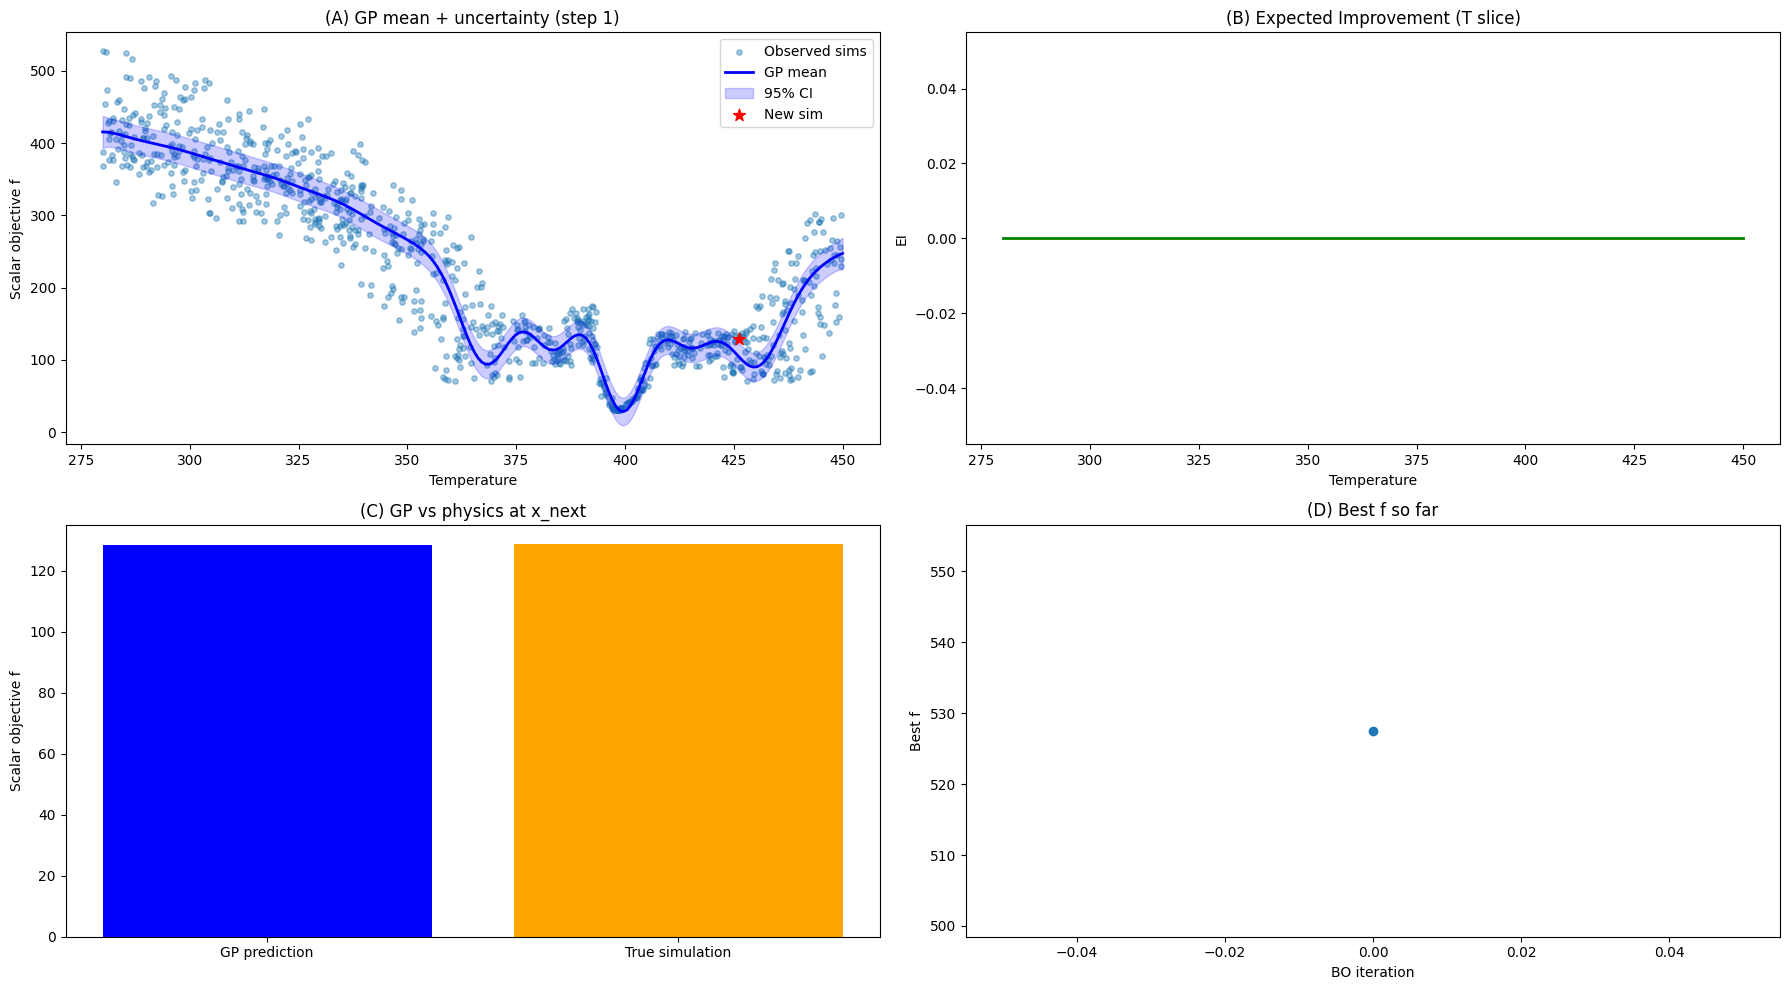


Step 1/30
x_next: [4.26219932e+02 1.47272825e-02 1.57353861e+00]
y_next: [-159.87492449  164.54482672  140.57508236 -141.25033447   92.59658626
   -0.31729472]
new scalar f: 128.57070648848062


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 495.29it/s]


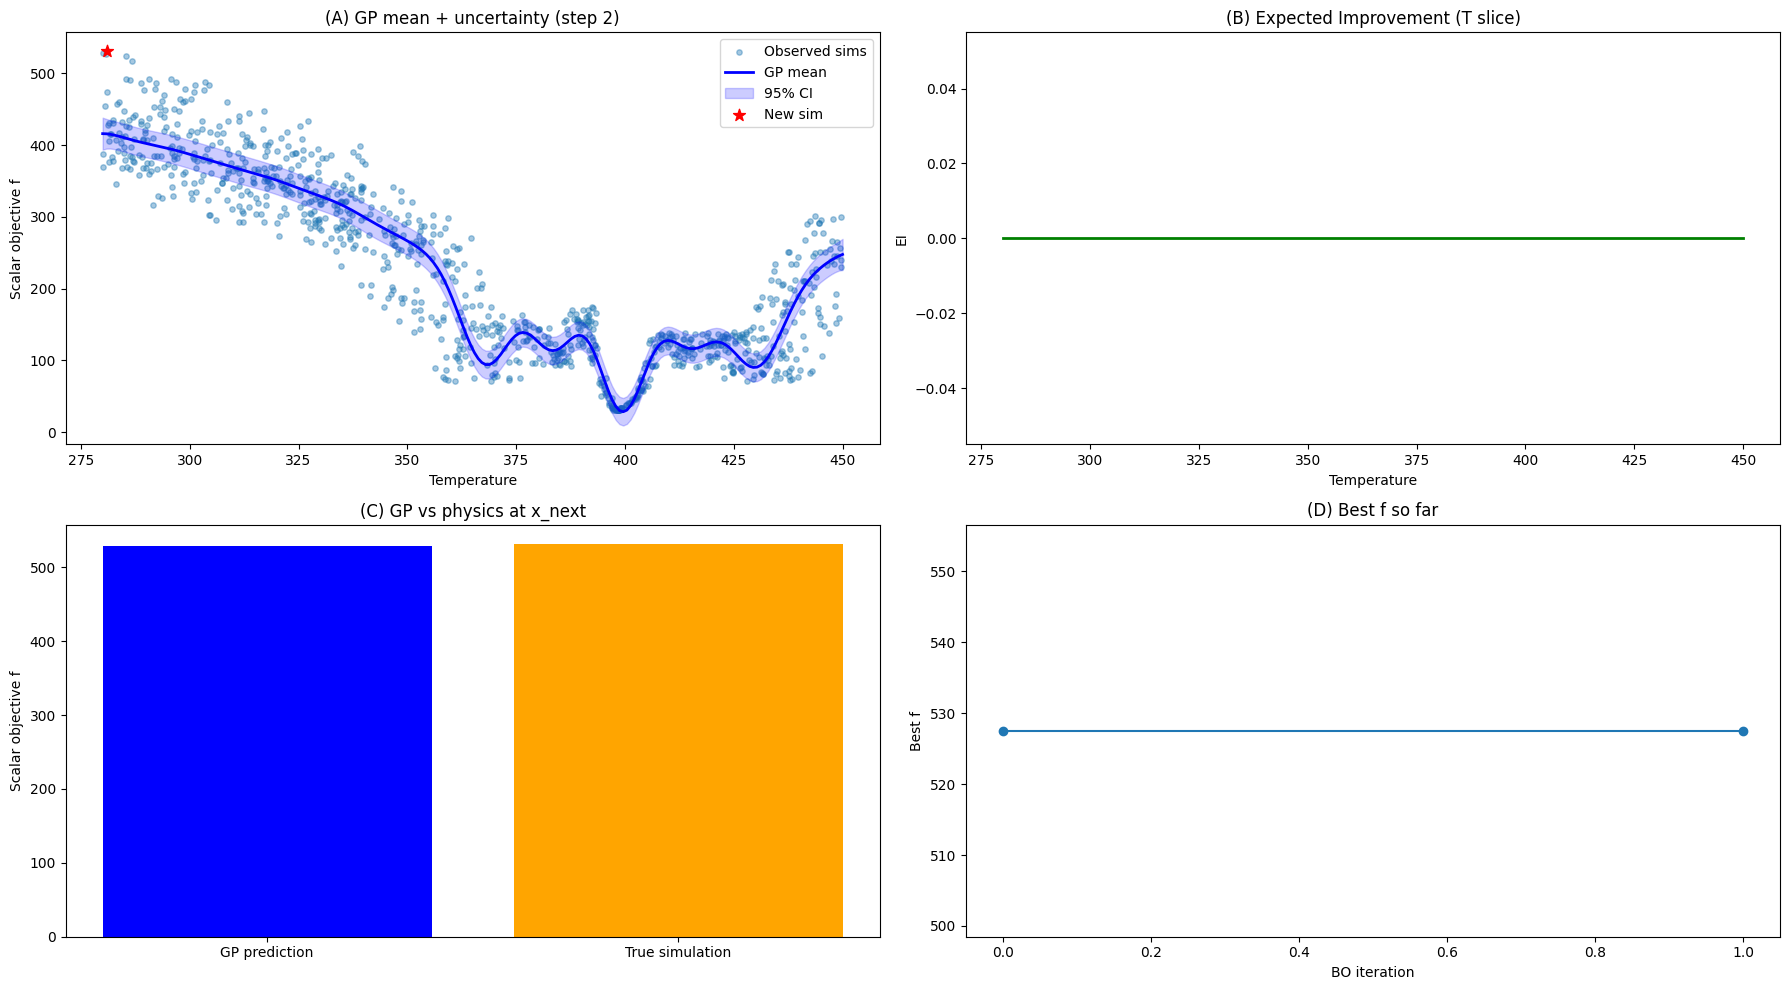


Step 2/30
x_next: [2.80900107e+02 2.27254380e-02 8.78007389e-01]
y_next: [ -57.50609824   56.32005127 -371.50225489  377.04395867 1005.4285126
    3.40445782]
new scalar f: 530.8742819315537


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 480.40it/s]


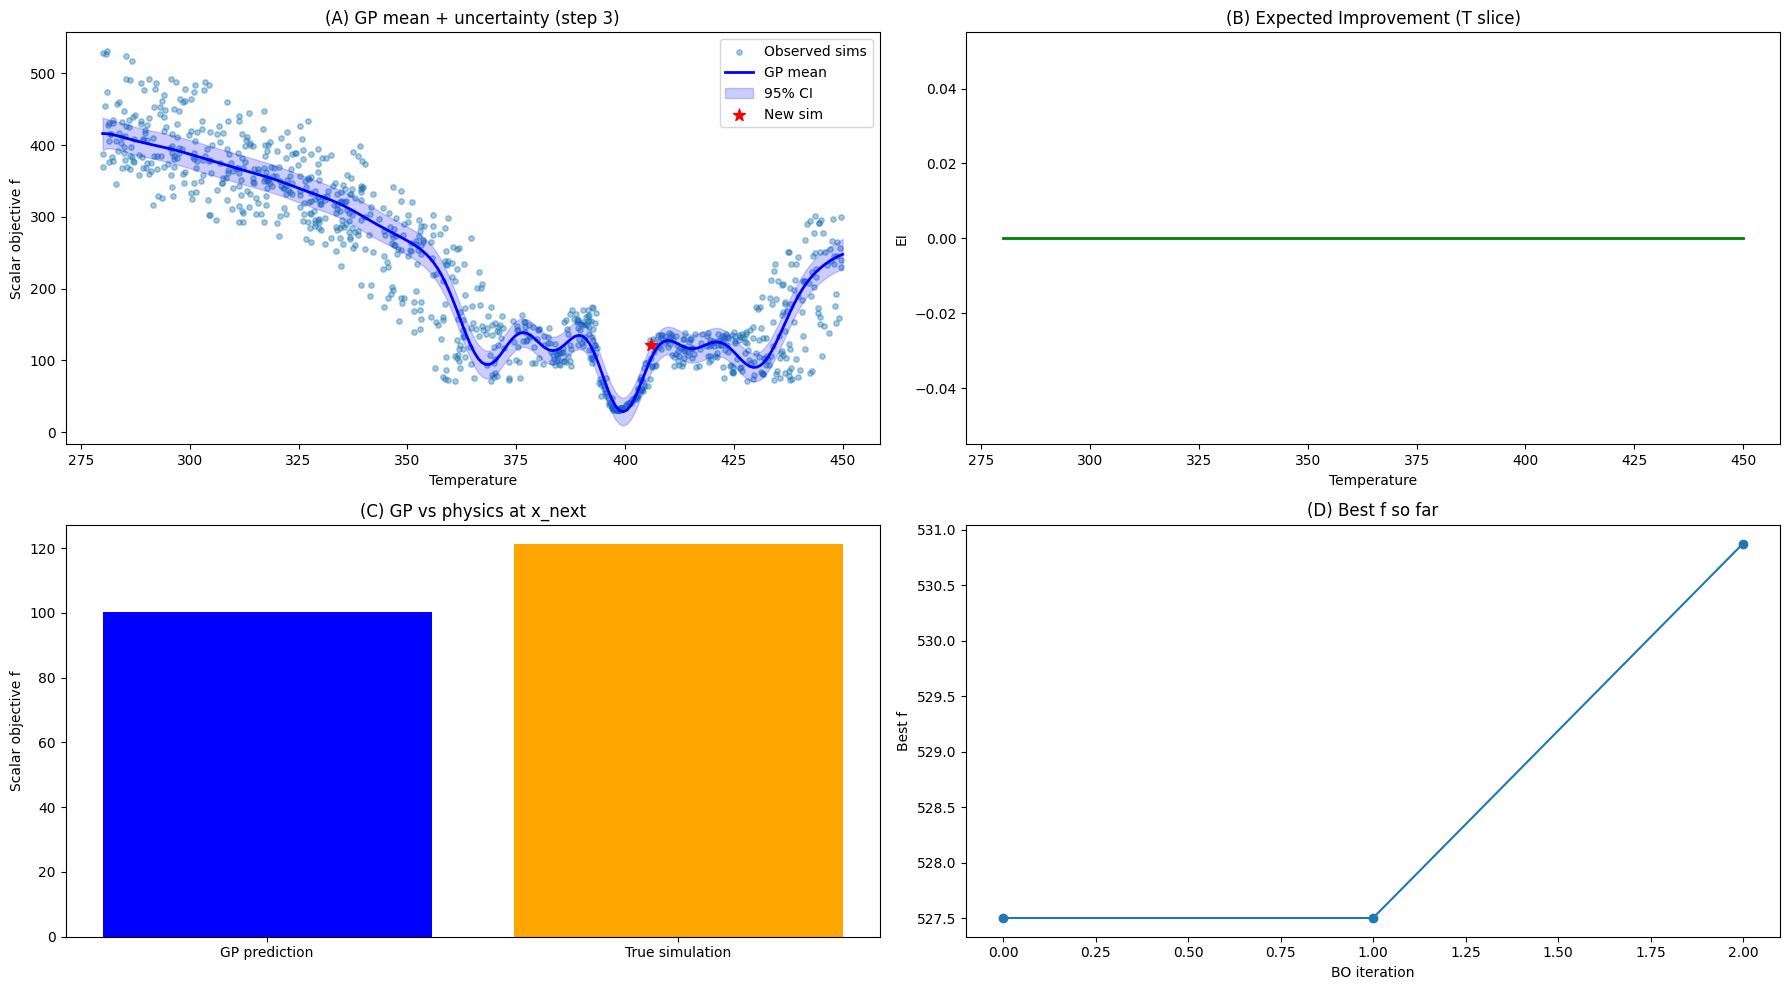


Step 3/30
x_next: [4.05982272e+02 2.21608248e-02 1.22388975e+00]
y_next: [-186.82294115  167.45472472   39.90445745  -65.43432864   74.86445371
   -0.21784313]
new scalar f: 121.15958921176839


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 477.90it/s]


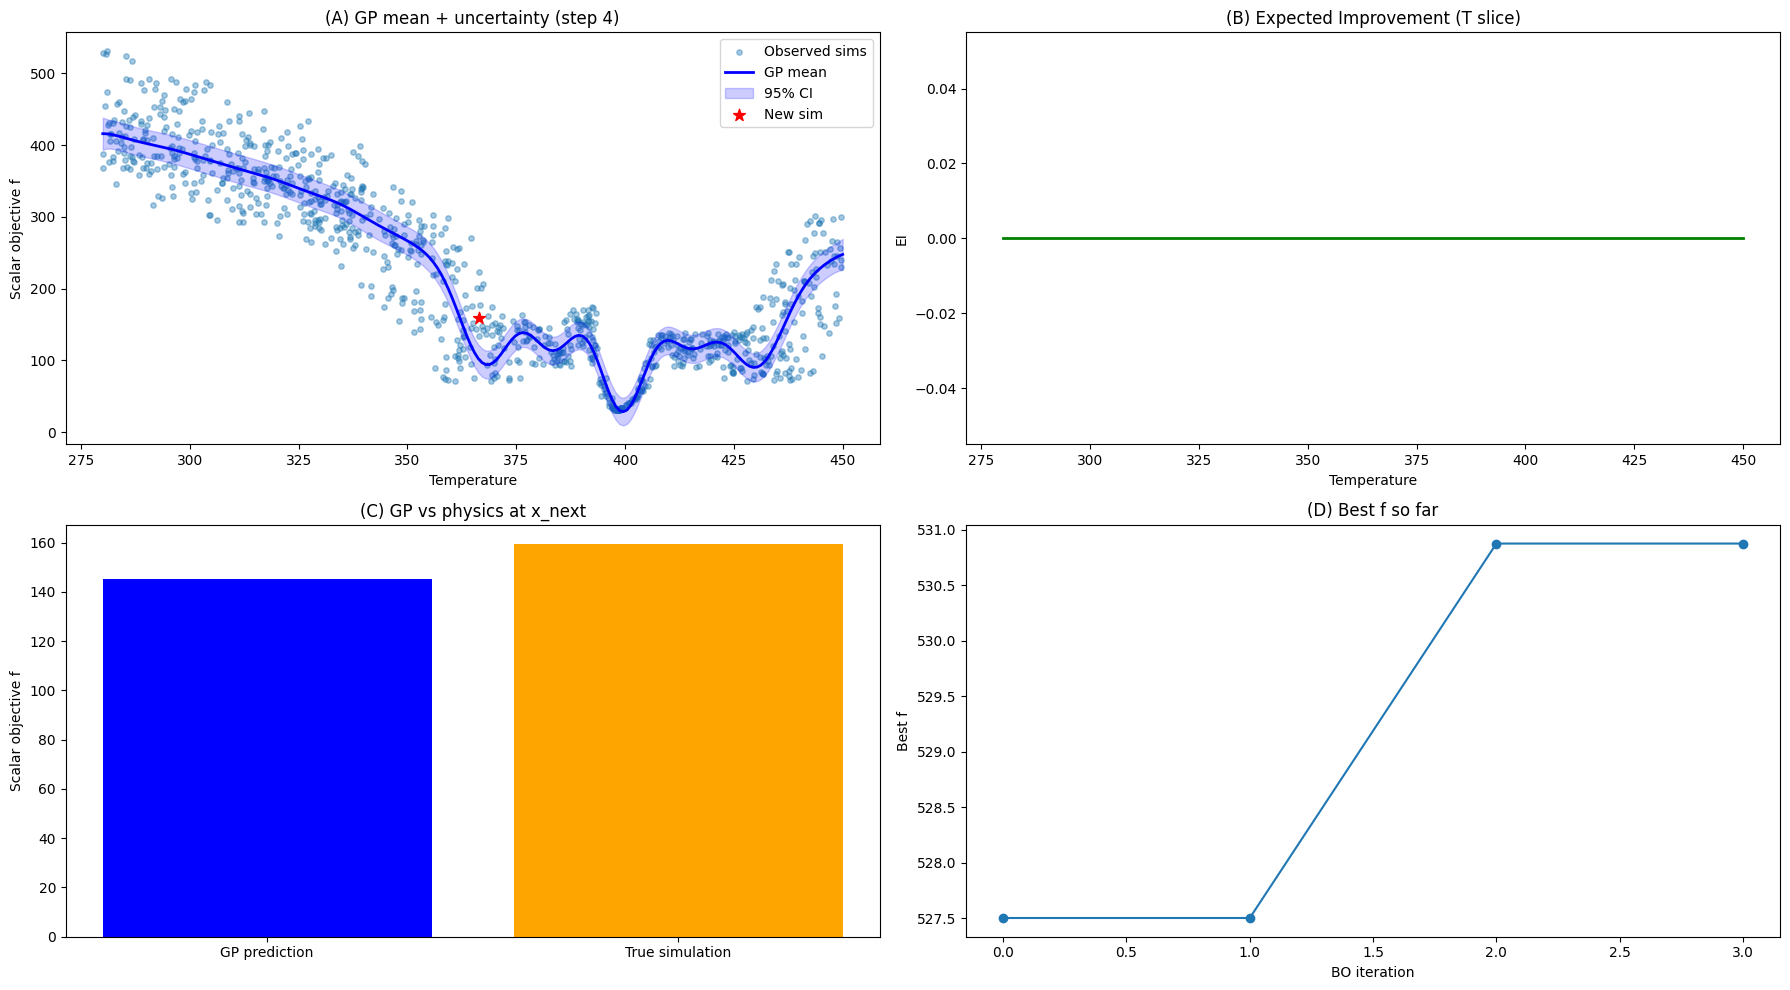


Step 4/30
x_next: [3.66383144e+02 2.11494314e-02 1.62339564e+00]
y_next: [-124.82286935  128.14169454 -181.8990597   183.09361459  190.35940654
    0.62675722]
new scalar f: 159.25055053748082


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 500.93it/s]


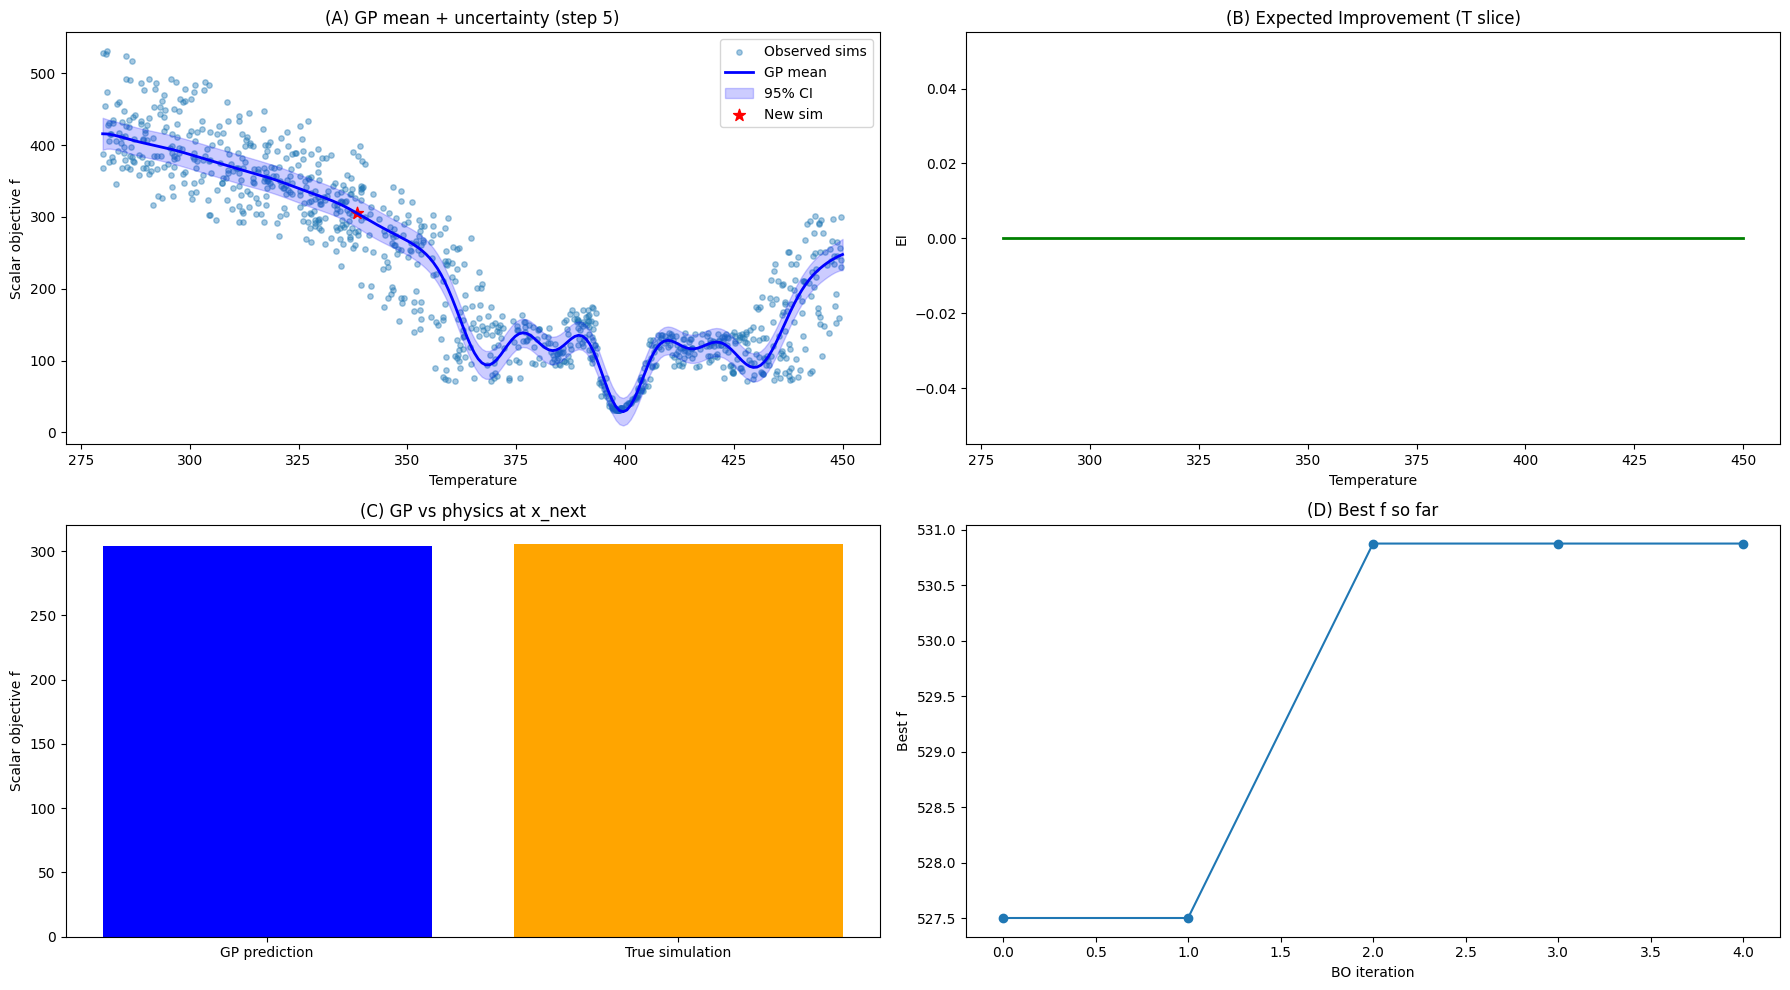


Step 5/30
x_next: [3.38547719e+02 1.90656593e-02 1.29359162e+00]
y_next: [ -95.68677642   94.524784   -237.81762421  239.93991077  515.8469222
    1.19957885]
new scalar f: 305.1858531013654


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 478.05it/s]


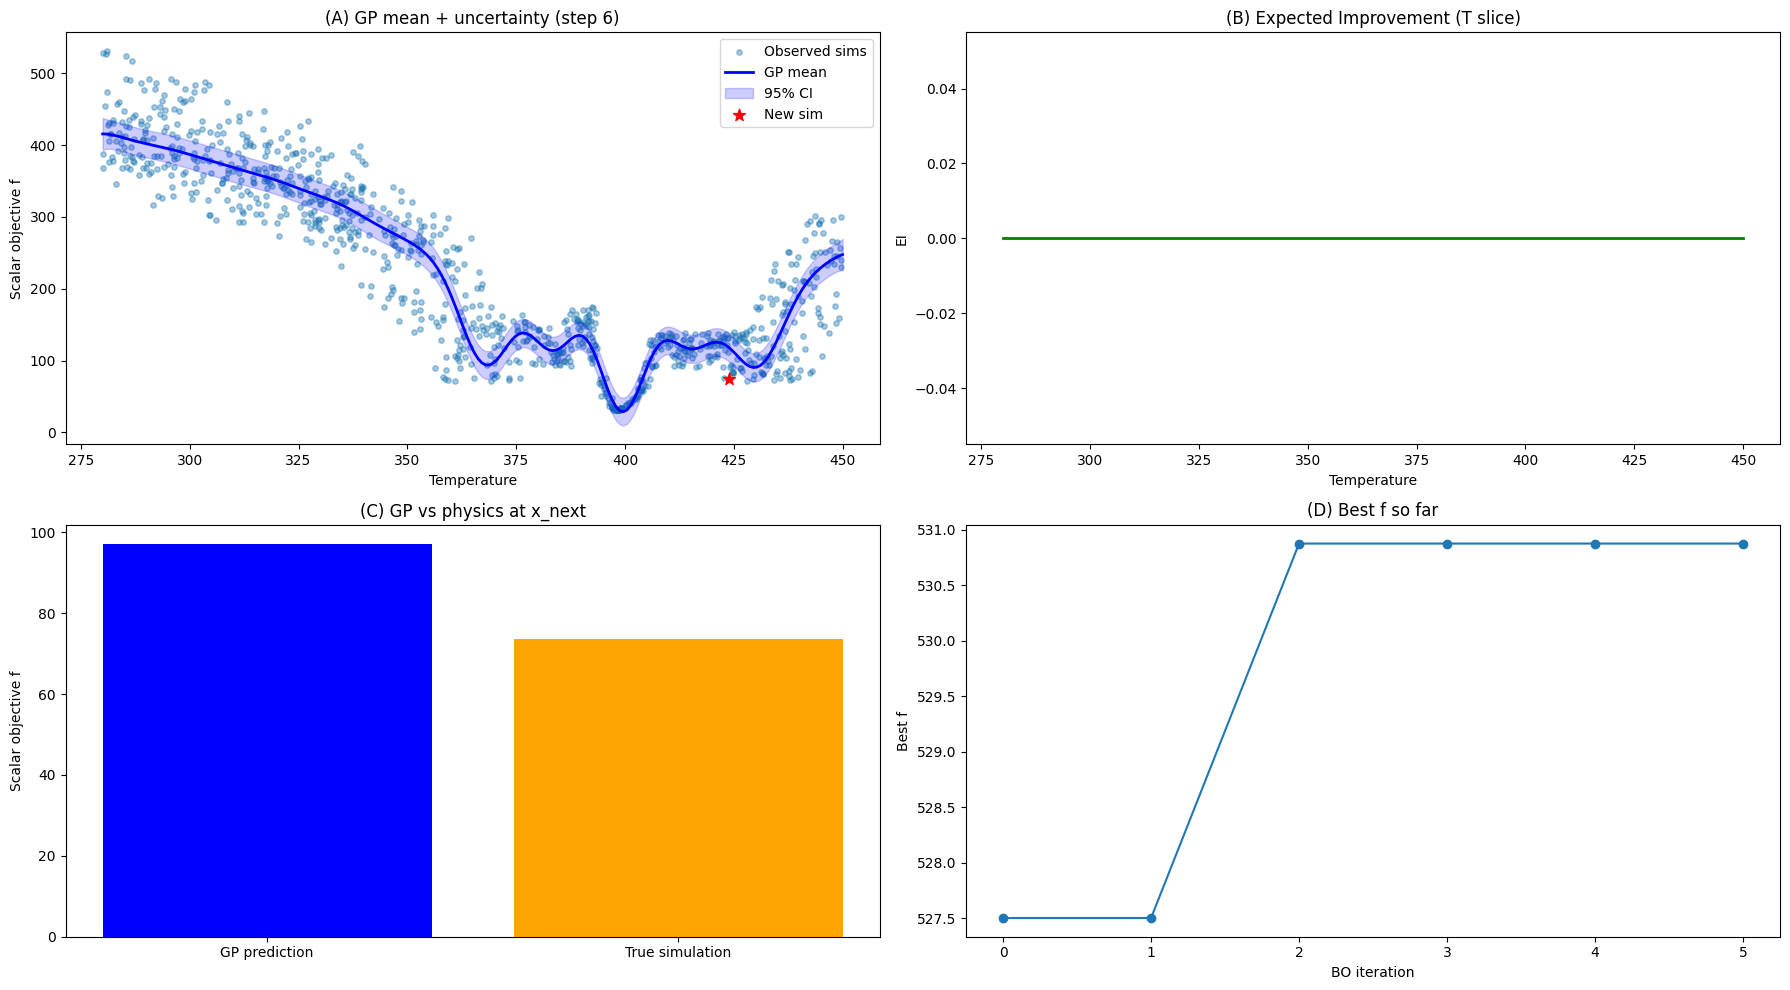


Step 6/30
x_next: [4.23852097e+02 2.29582457e-02 1.55185123e+00]
y_next: [-137.74387326  139.78754303  159.3386021  -160.328743      7.56115868
   -0.51067263]
new scalar f: 73.67435085203061


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 499.45it/s]


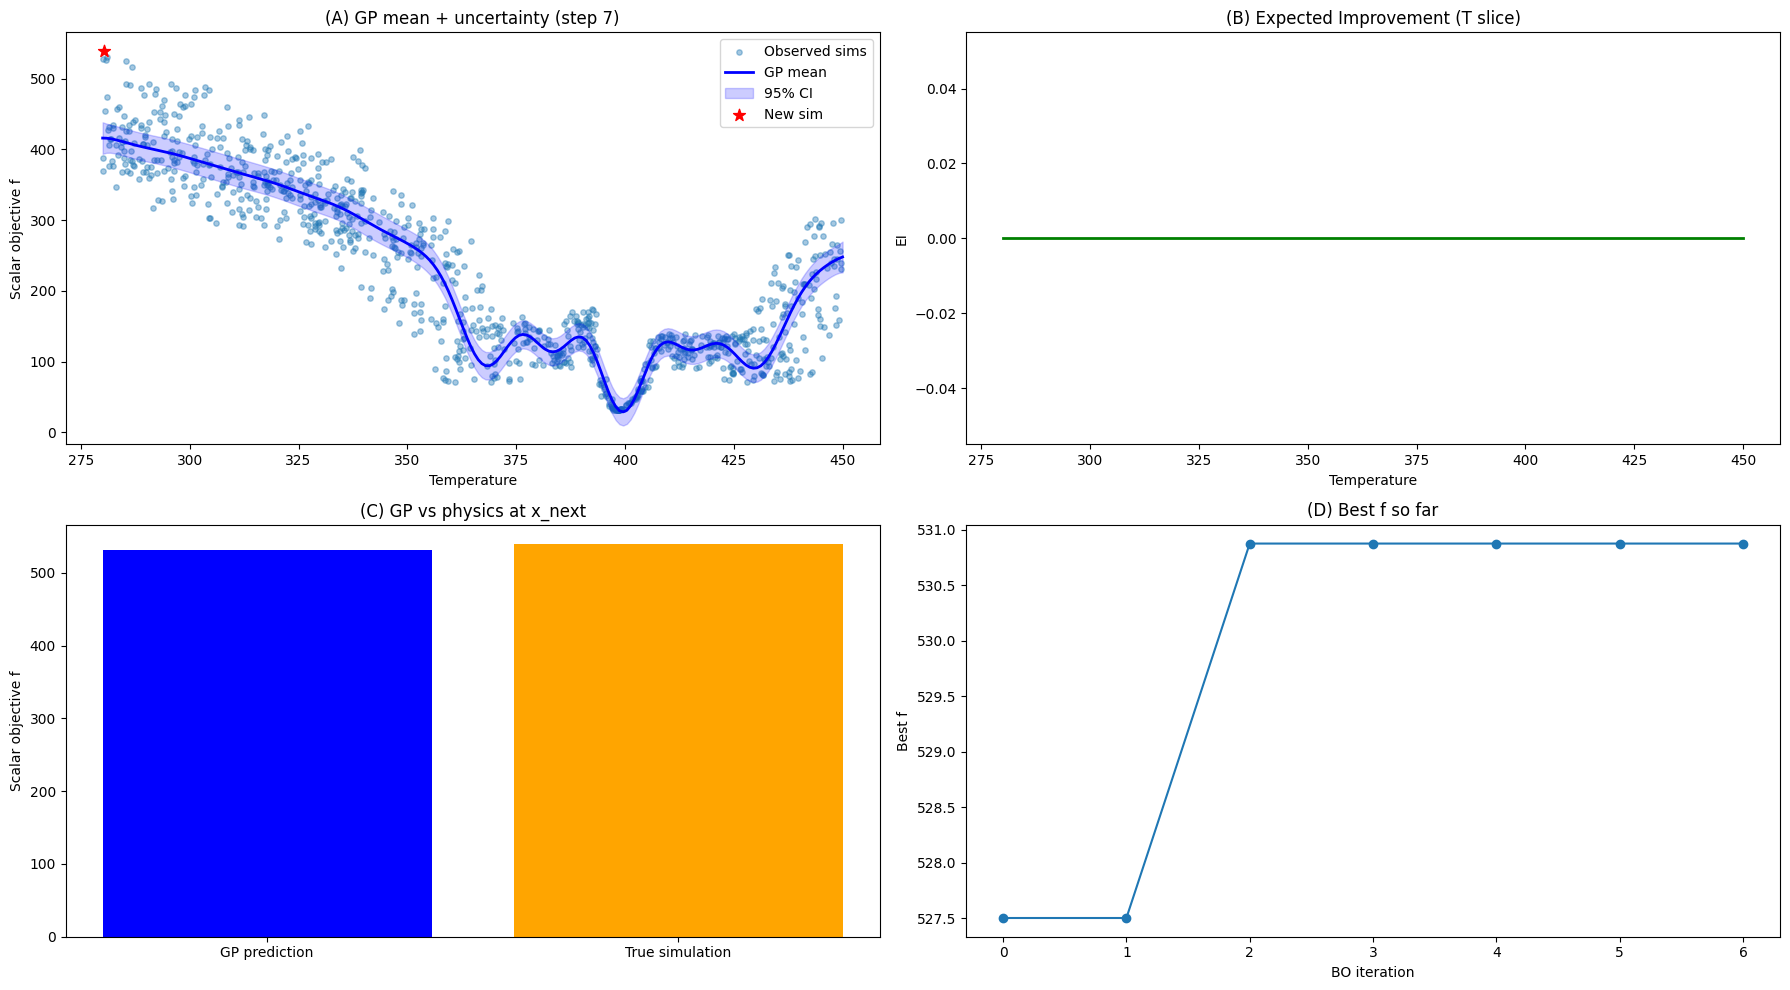


Step 7/30
x_next: [2.80349886e+02 2.34994618e-02 8.79453469e-01]
y_next: [ -57.47456472   56.23435439 -375.41392537  381.14733164 1021.67199264
    3.53310046]
new scalar f: 538.9531735138214


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 495.76it/s]


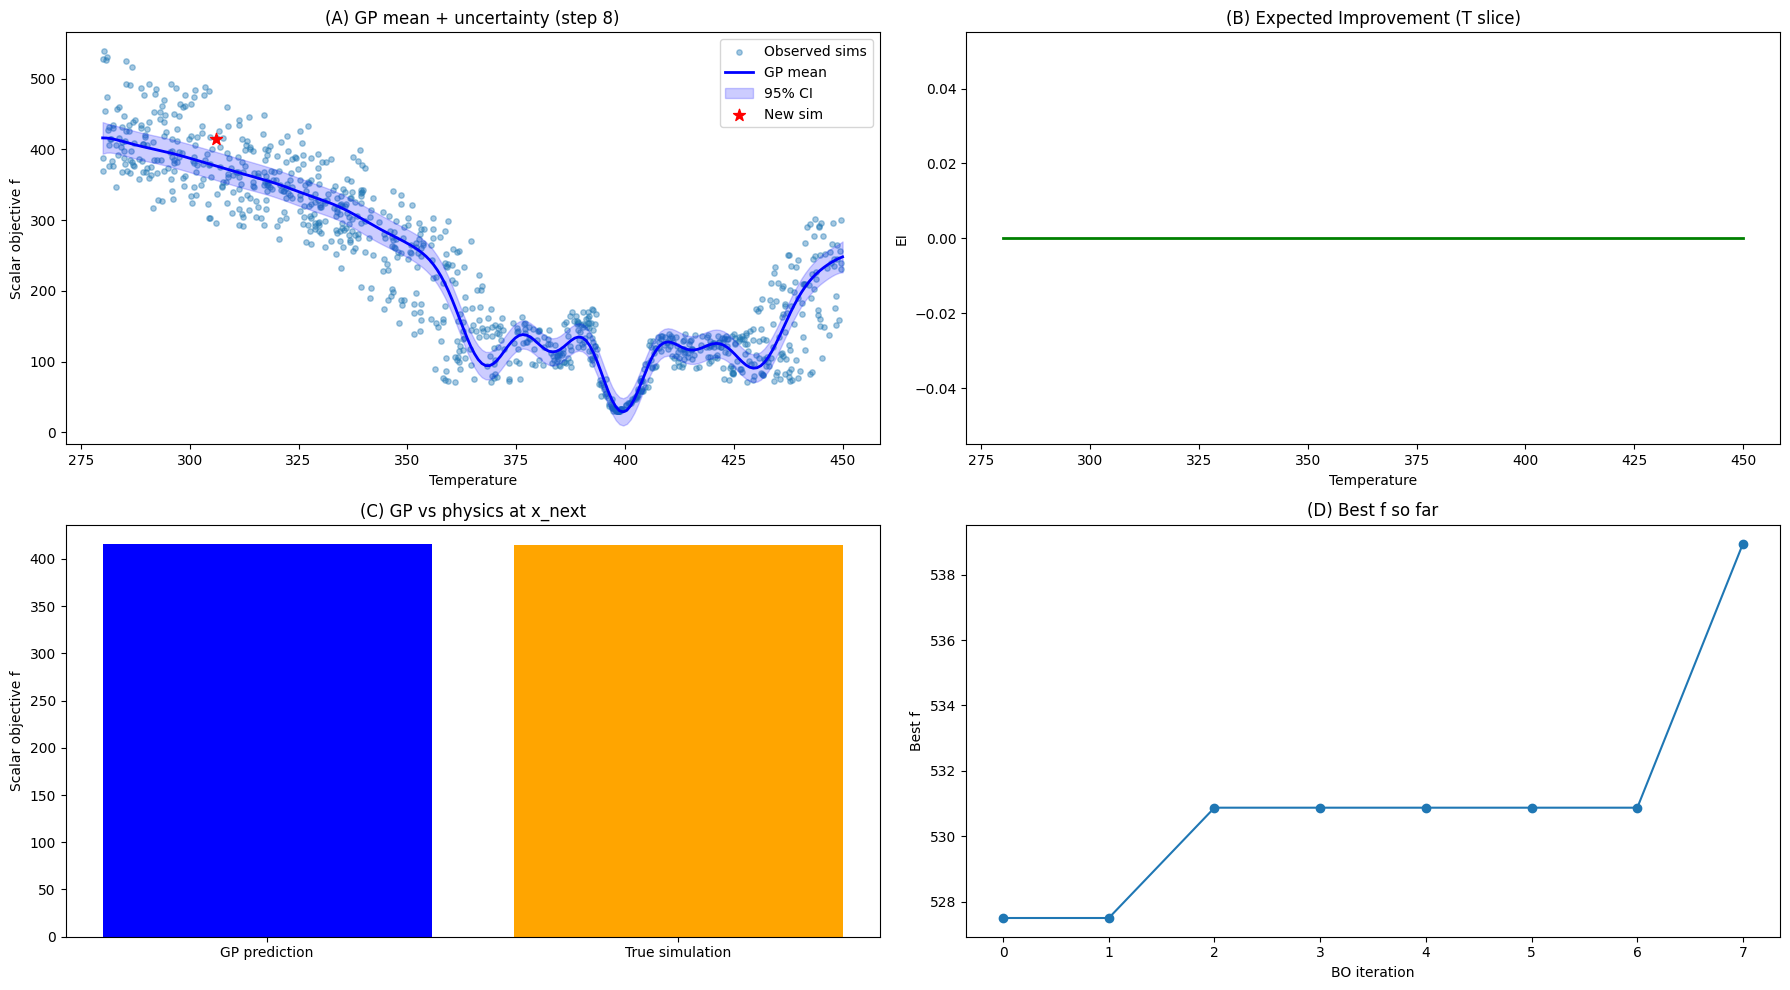


Step 8/30
x_next: [3.05934057e+02 2.17073976e-02 1.17276304e+00]
y_next: [ -68.77561332   67.57304709 -295.52773362  299.23401713  761.04677836
    2.22236347]
new scalar f: 414.30991272342925


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 460.35it/s]


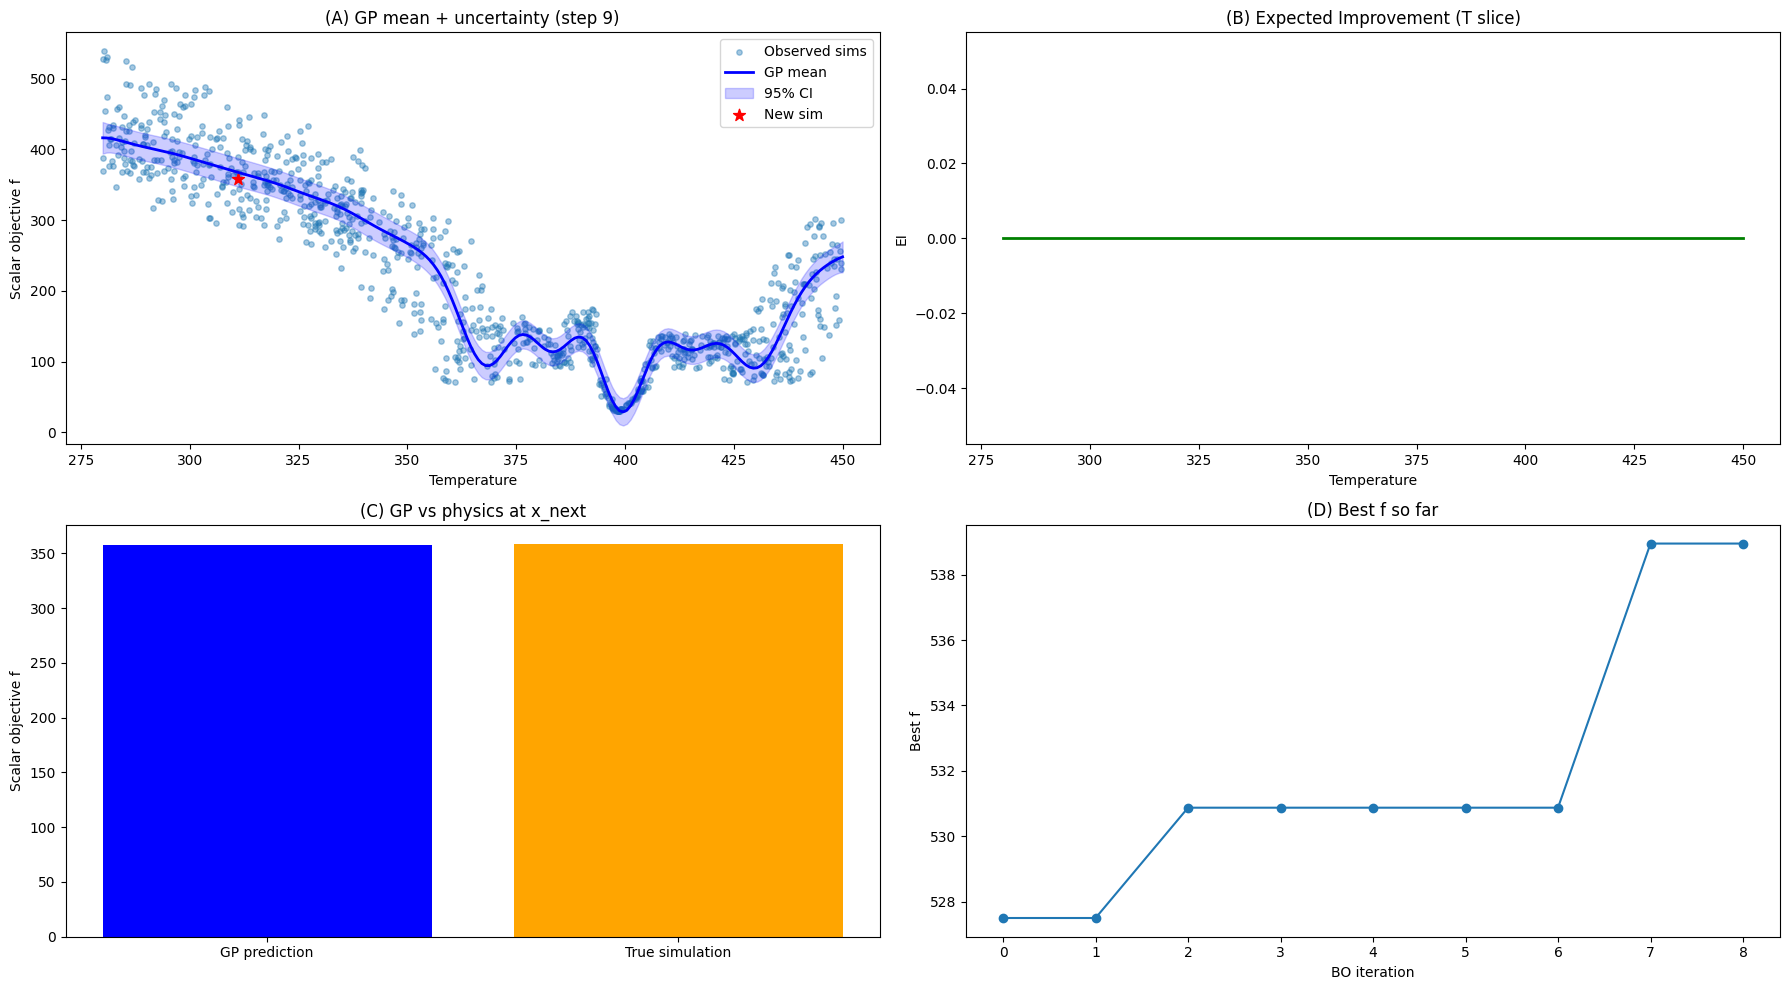


Step 9/30
x_next: [3.11067816e+02 1.31092757e-02 8.84247544e-01]
y_next: [ -95.69060864   94.53563162 -287.20844209  289.76373026  621.51295507
    1.44342981]
new scalar f: 358.02429334257124


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 489.35it/s]


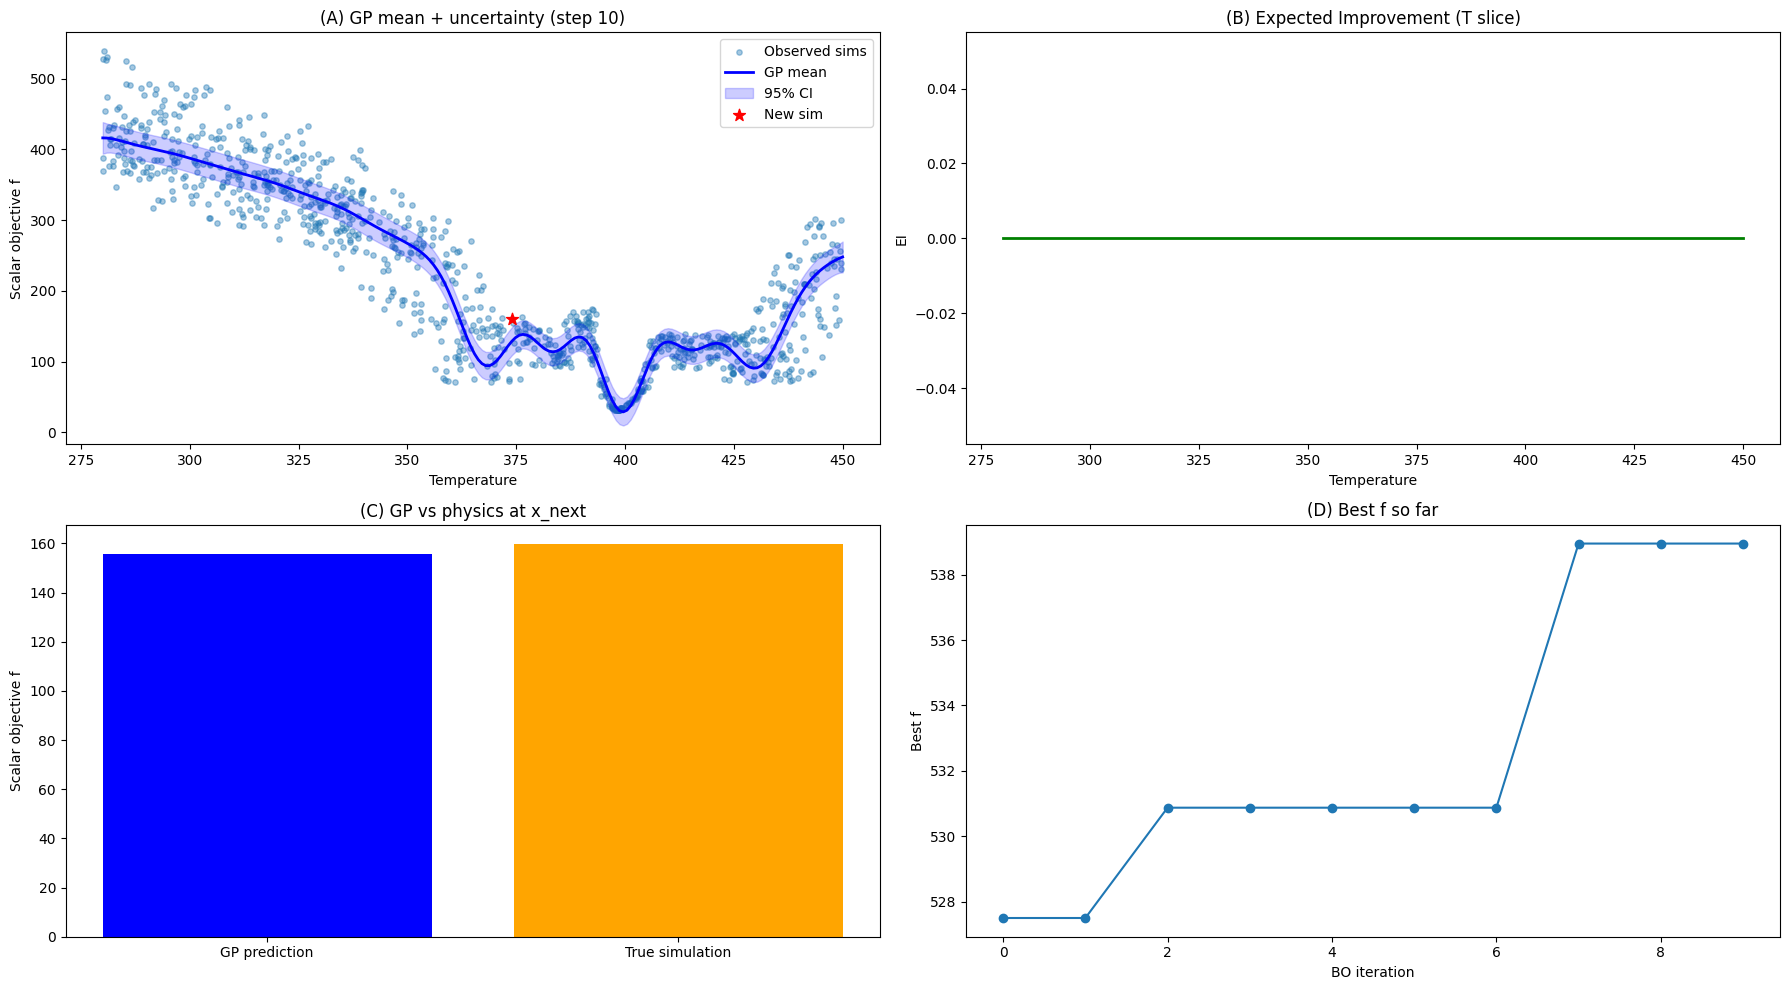


Step 10/30
x_next: [3.74076446e+02 1.53141279e-02 9.29748874e-01]
y_next: [-166.02893859  165.33218201 -197.13827142  198.0150004   153.85219206
    0.39779275]
new scalar f: 159.59218703604282


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 515.09it/s]


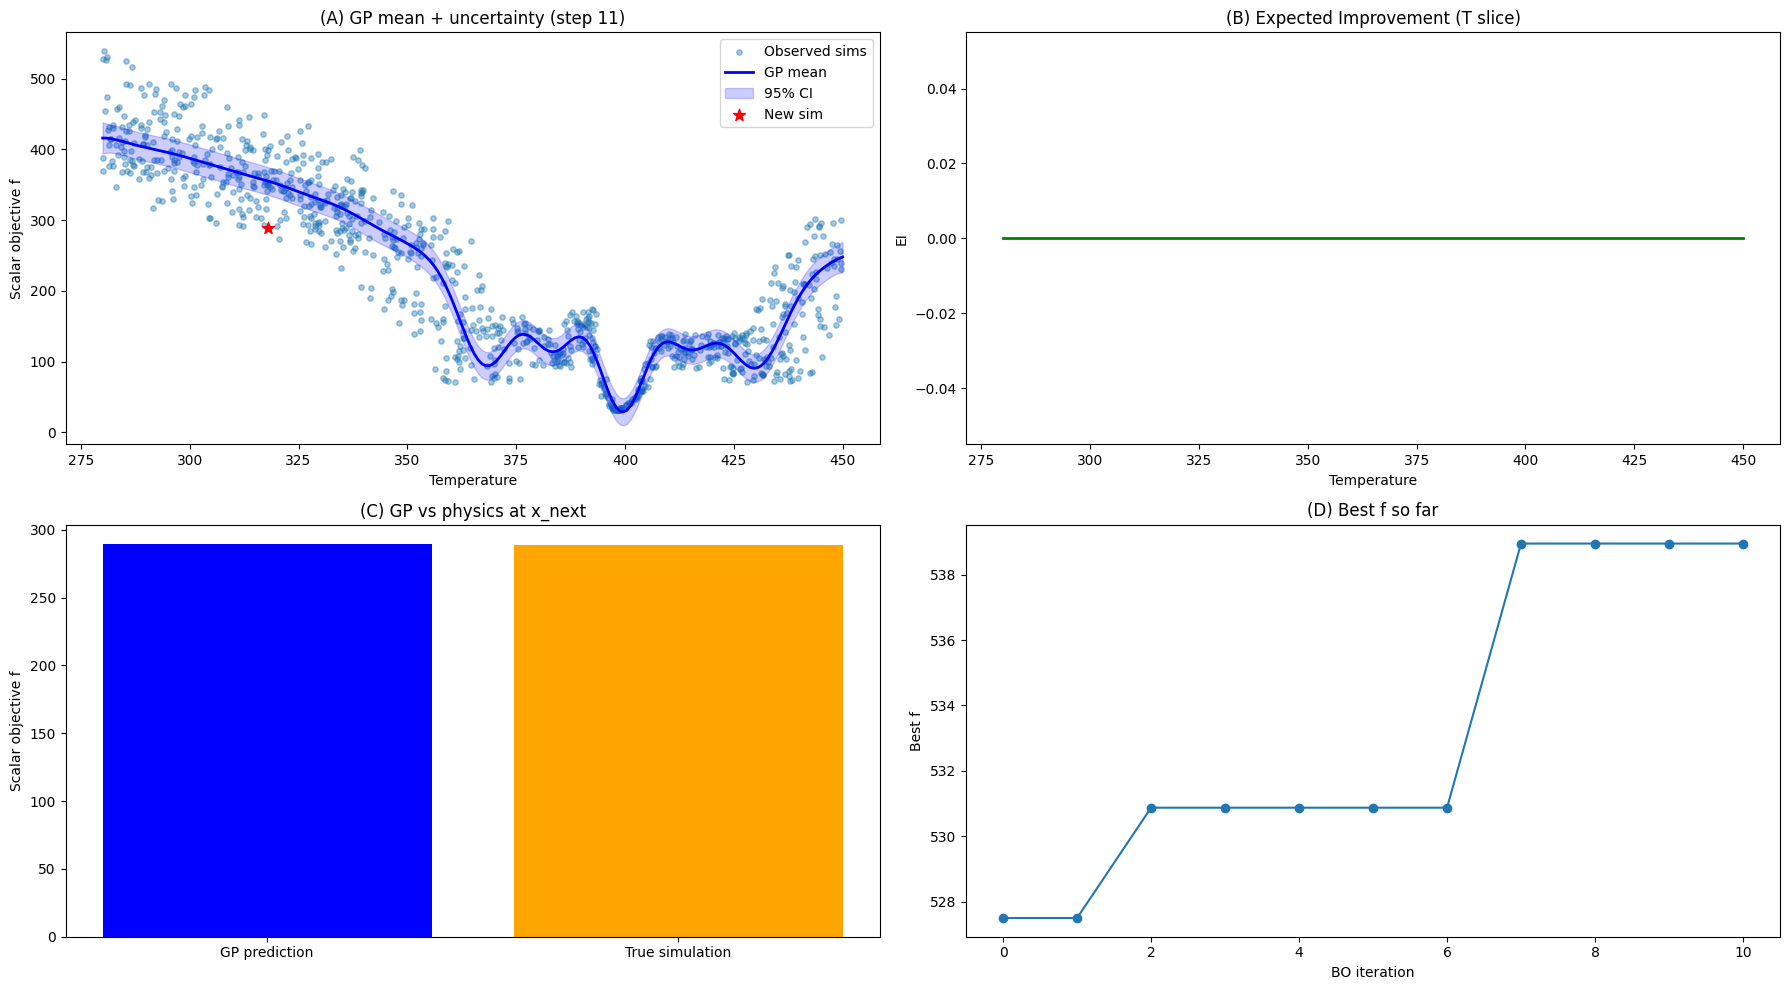


Step 11/30
x_next: [3.18096502e+02 1.40120965e-02 1.42645311e+00]
y_next: [ -95.70250419   94.56932537 -225.04228553  227.02529527  483.26569073
    1.11794641]
new scalar f: 288.91750805427364


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 480.41it/s]


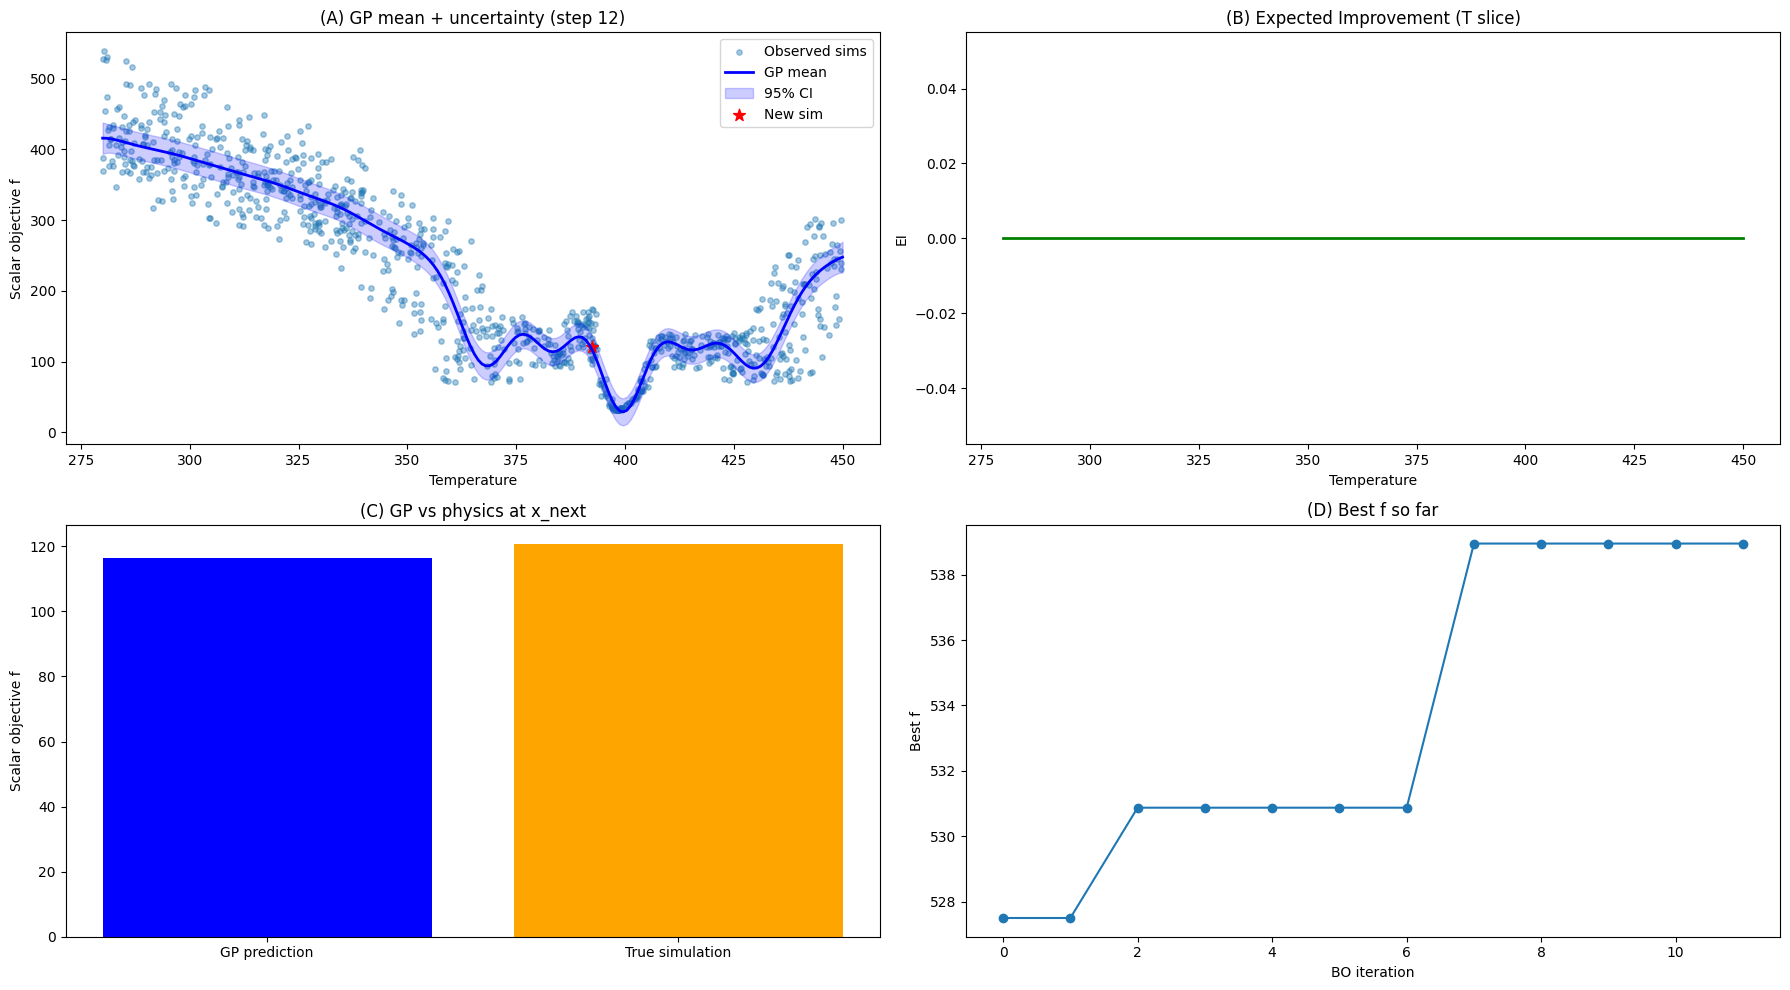


Step 12/30
x_next: [3.92406816e+02 1.67640291e-02 1.25636639e+00]
y_next: [-176.86601224  152.22615203  -29.62525773   68.66575224   88.94747351
    0.17977165]
new scalar f: 120.5868127698749


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 516.11it/s]


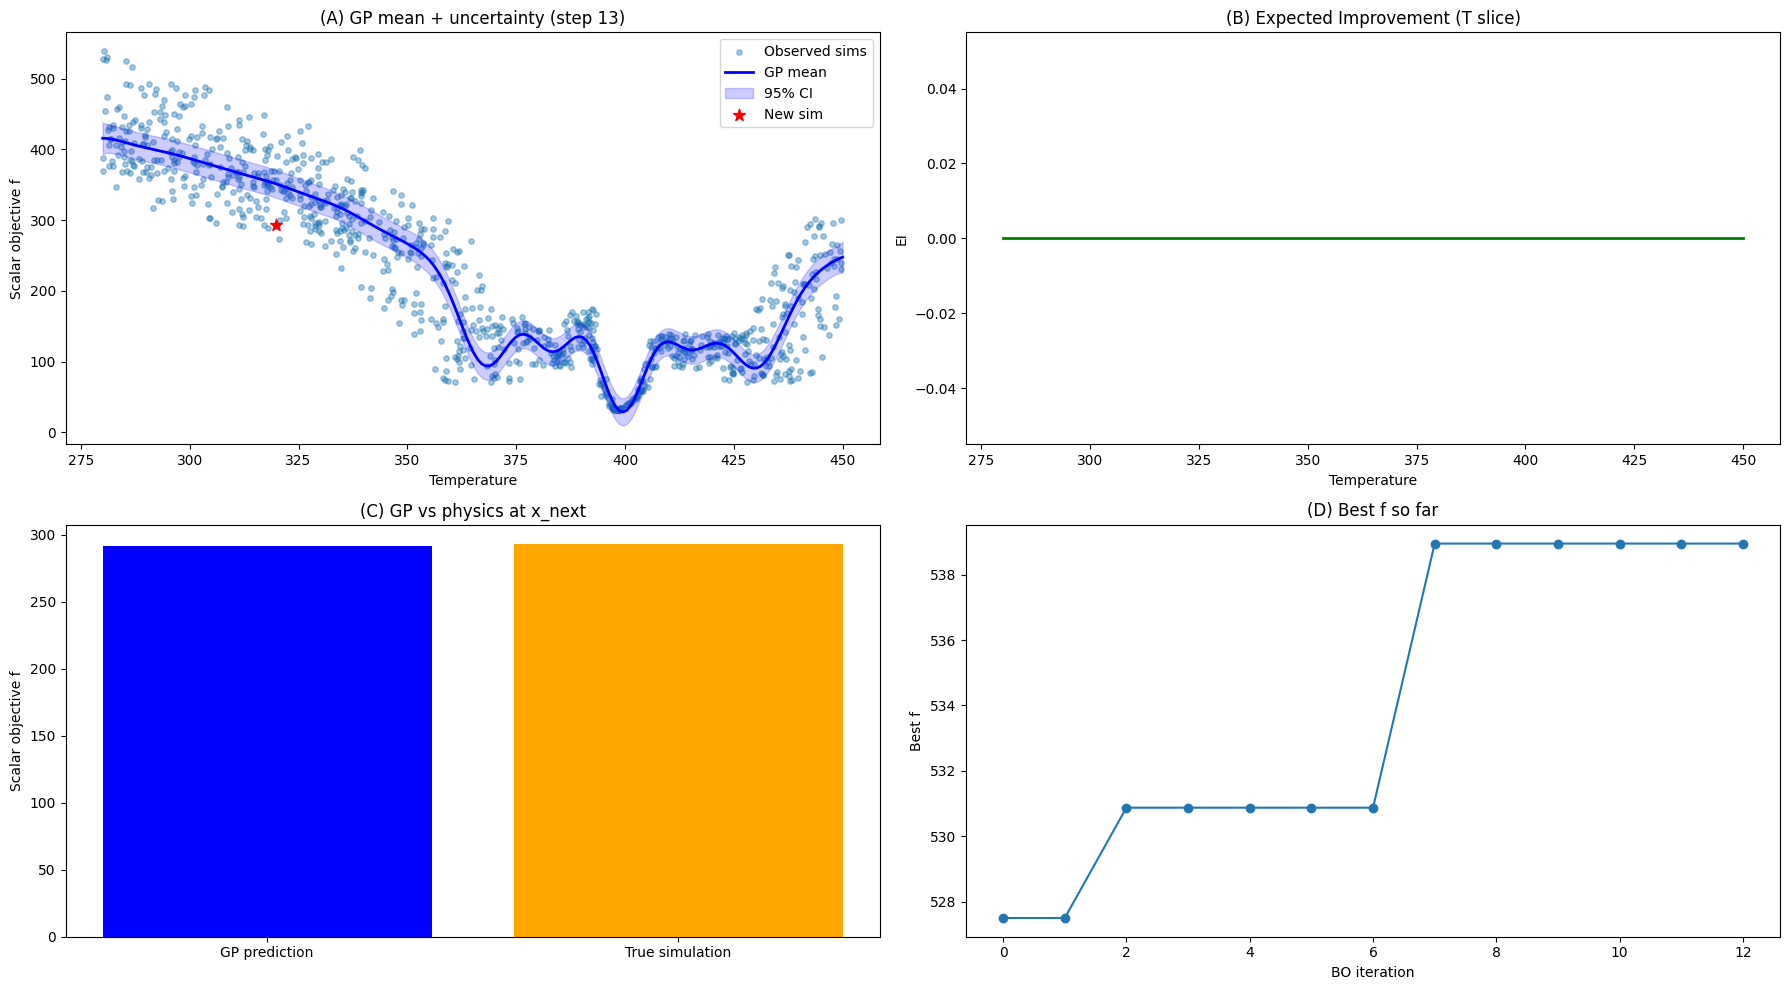


Step 13/30
x_next: [3.19802394e+02 1.53869303e-02 1.54104022e+00]
y_next: [ -90.50622289   94.40400038 -221.37043558  223.40965771  491.43376758
    1.15998879]
new scalar f: 292.918883979269


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 496.29it/s]


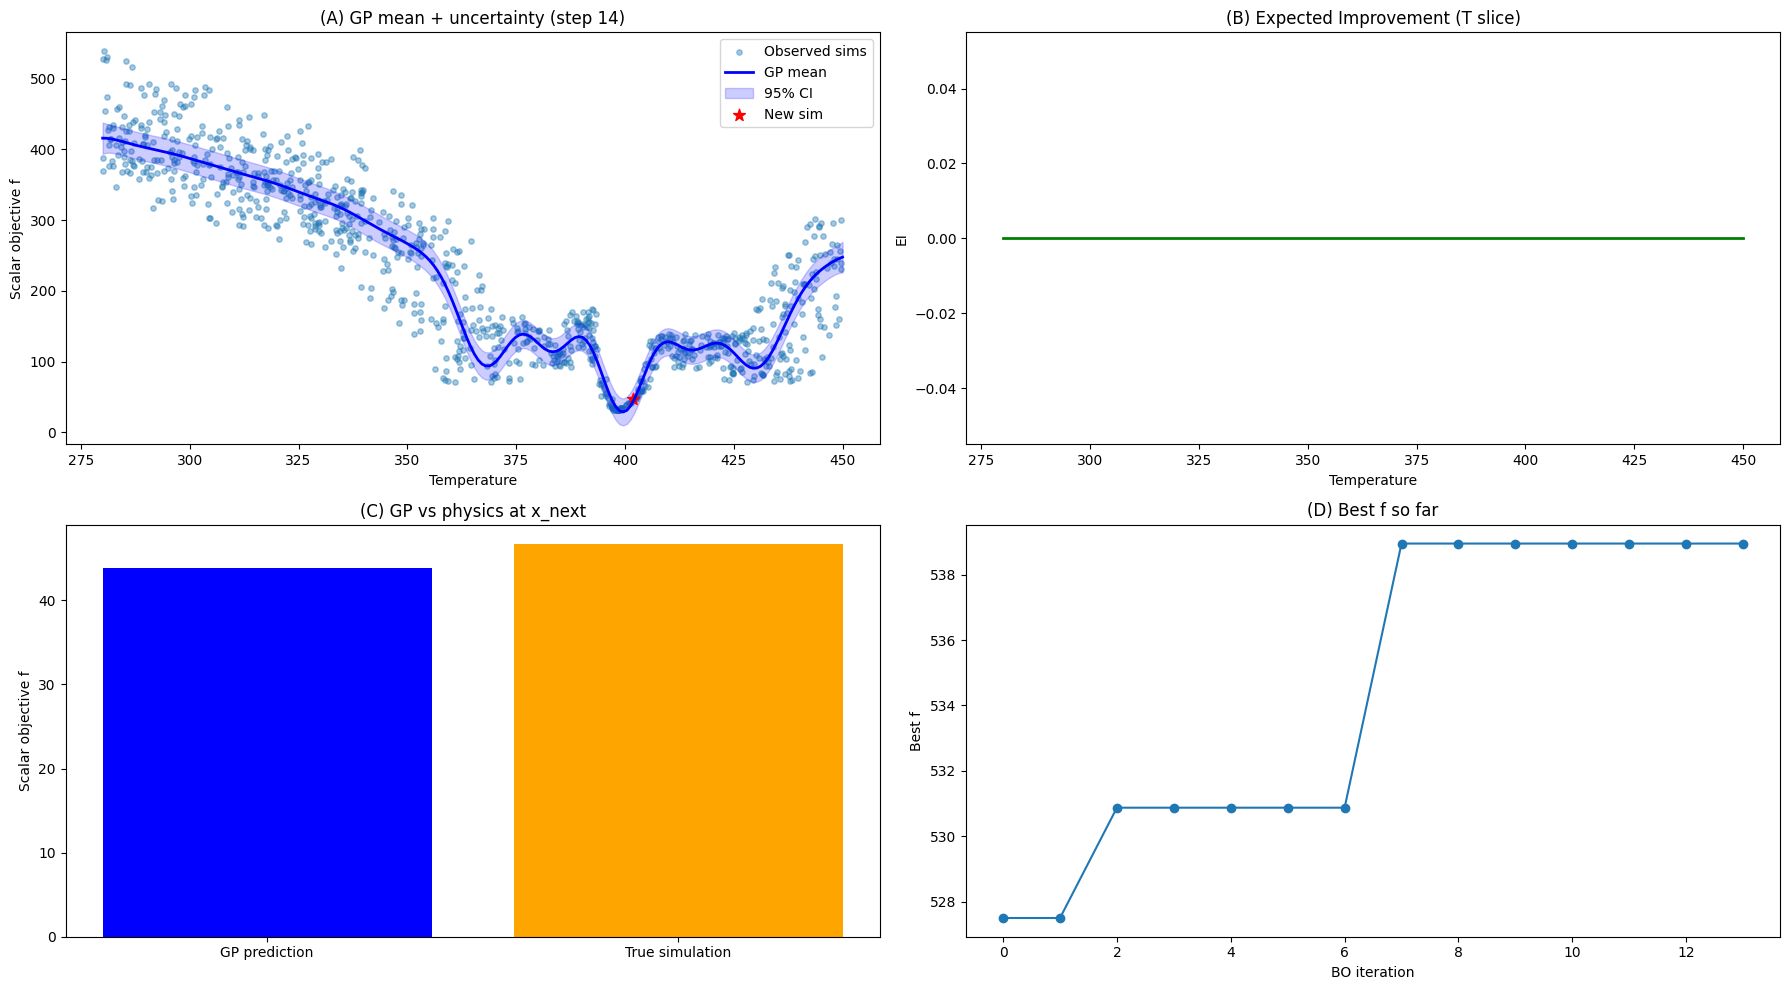


Step 14/30
x_next: [4.01807136e+02 1.91530968e-02 1.22125697e+00]
y_next: [-1.21399919e+02  9.30500631e+01  1.57431607e+00 -1.23066596e+01
  2.33893346e-01 -9.69123802e-03]
new scalar f: 46.64197823309891


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 491.22it/s]


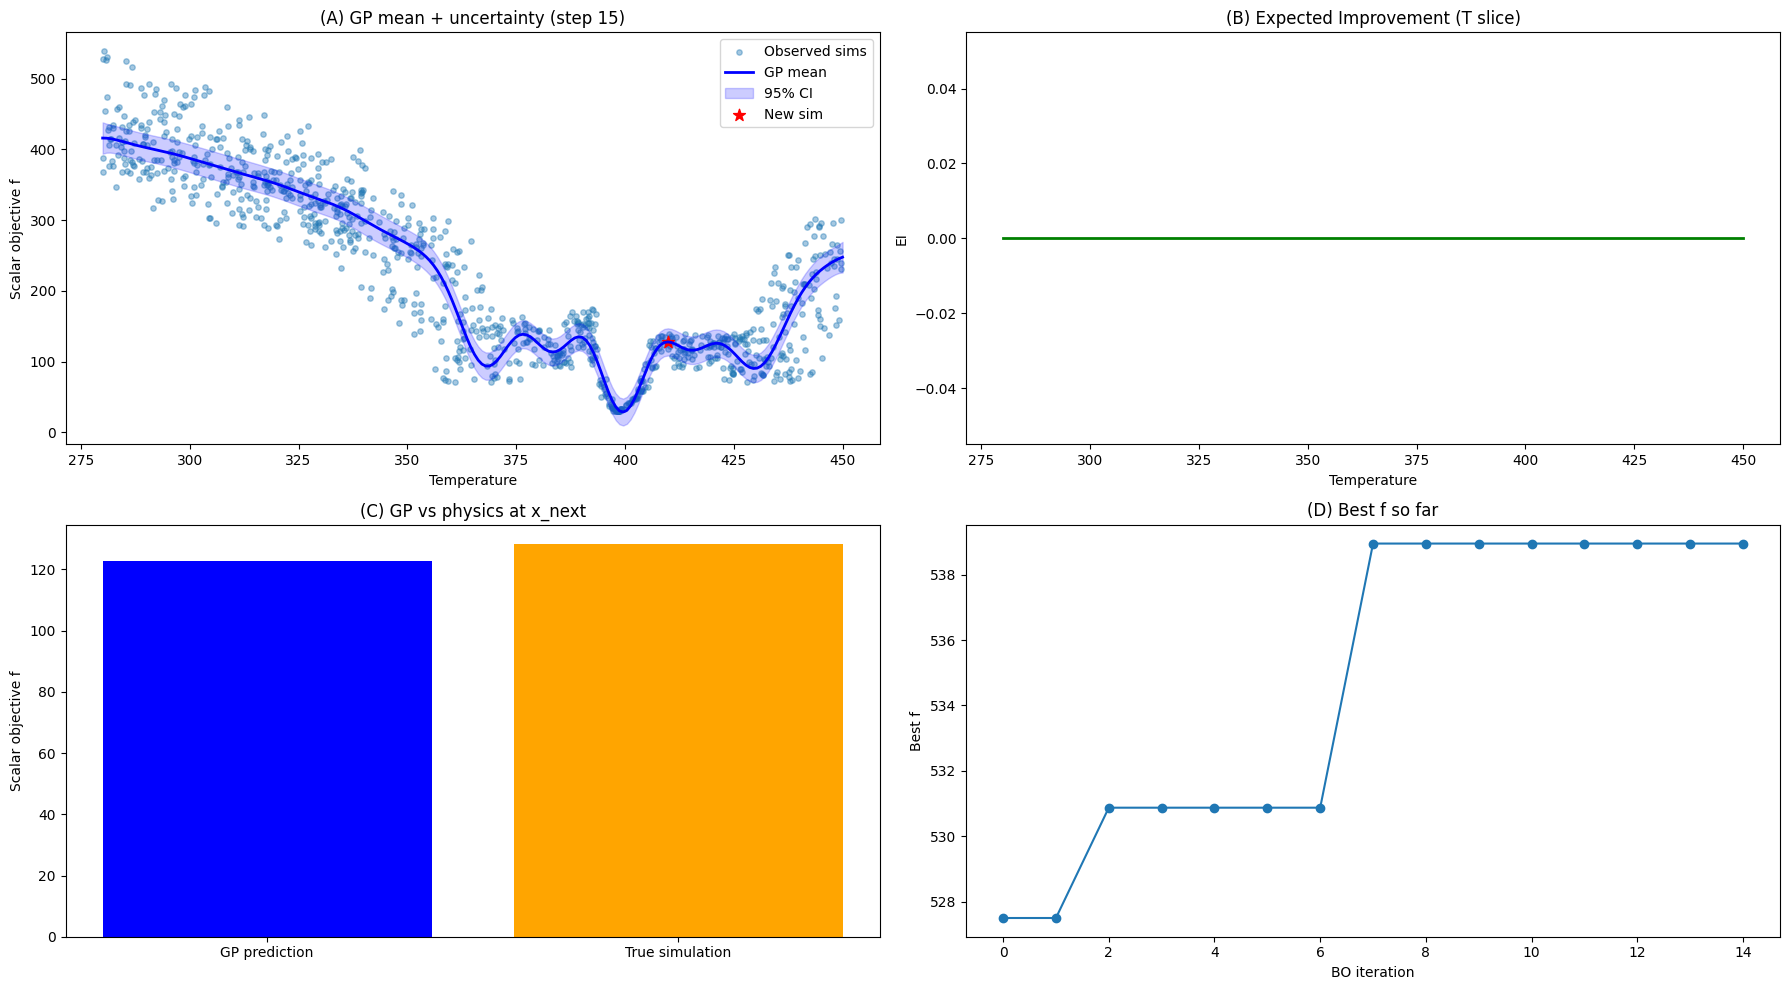


Step 15/30
x_next: [4.09791765e+02 2.08136752e-02 1.11512225e+00]
y_next: [-187.53031151  184.54758292   95.5937908  -101.14627592   71.81740261
   -0.21646317]
new scalar f: 128.1824927679709


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 488.59it/s]


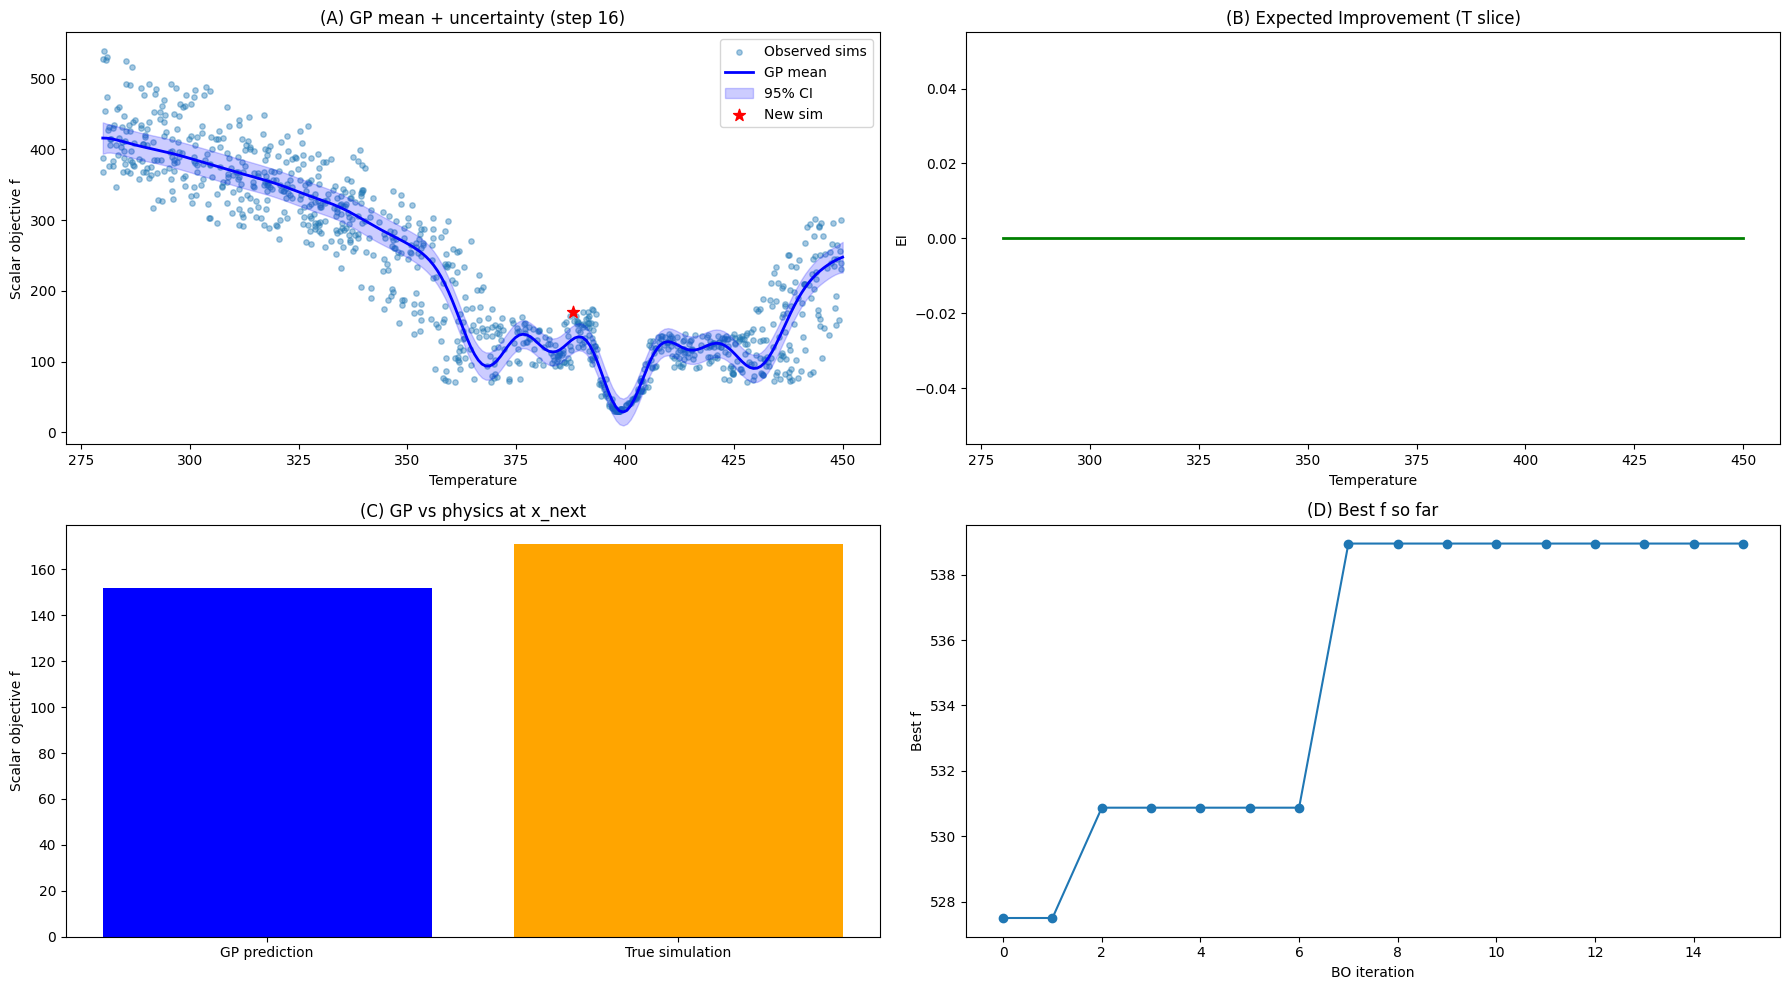


Step 16/30
x_next: [3.88059058e+02 1.45408825e-02 9.84533560e-01]
y_next: [-189.66881255  177.99779204  -75.15905704   98.83572146  163.65051303
    0.29957761]
new scalar f: 170.82415253239134


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 457.91it/s]


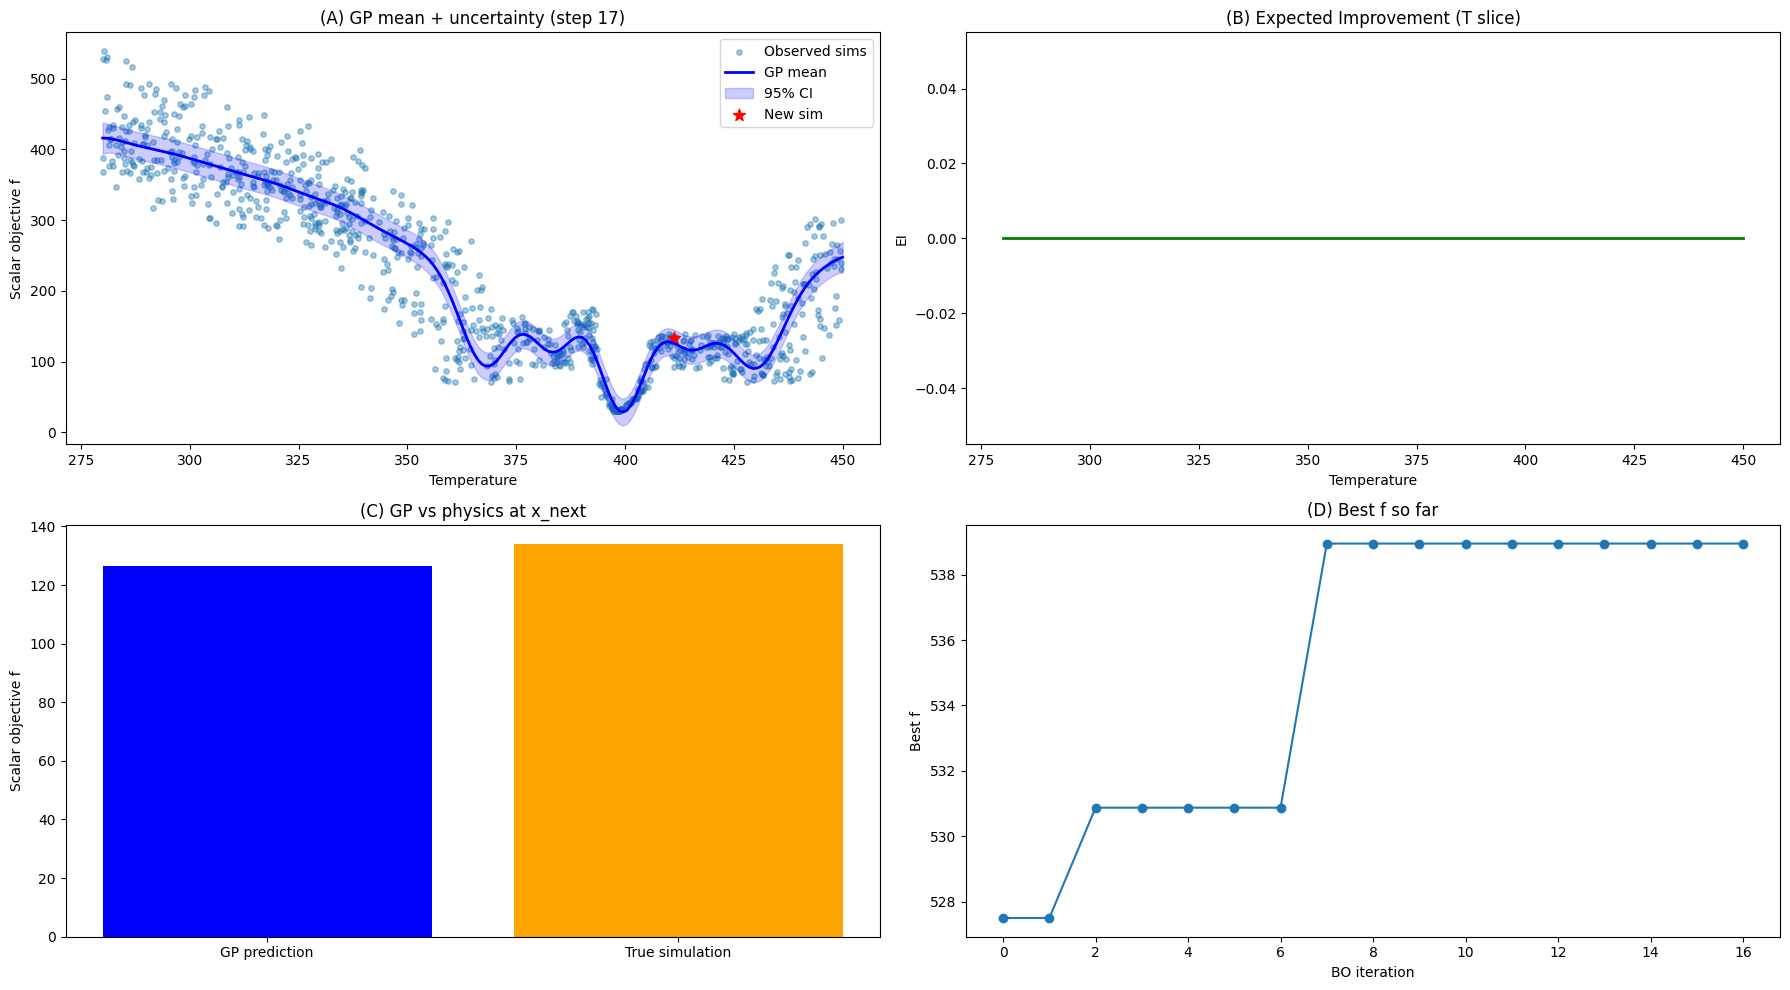


Step 17/30
x_next: [4.11381513e+02 1.36318310e-02 1.33930207e+00]
y_next: [-189.73619315  177.40707315   53.98153237  -71.73805721   90.28033163
   -0.23635783]
new scalar f: 133.84370239010448


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 487.01it/s]


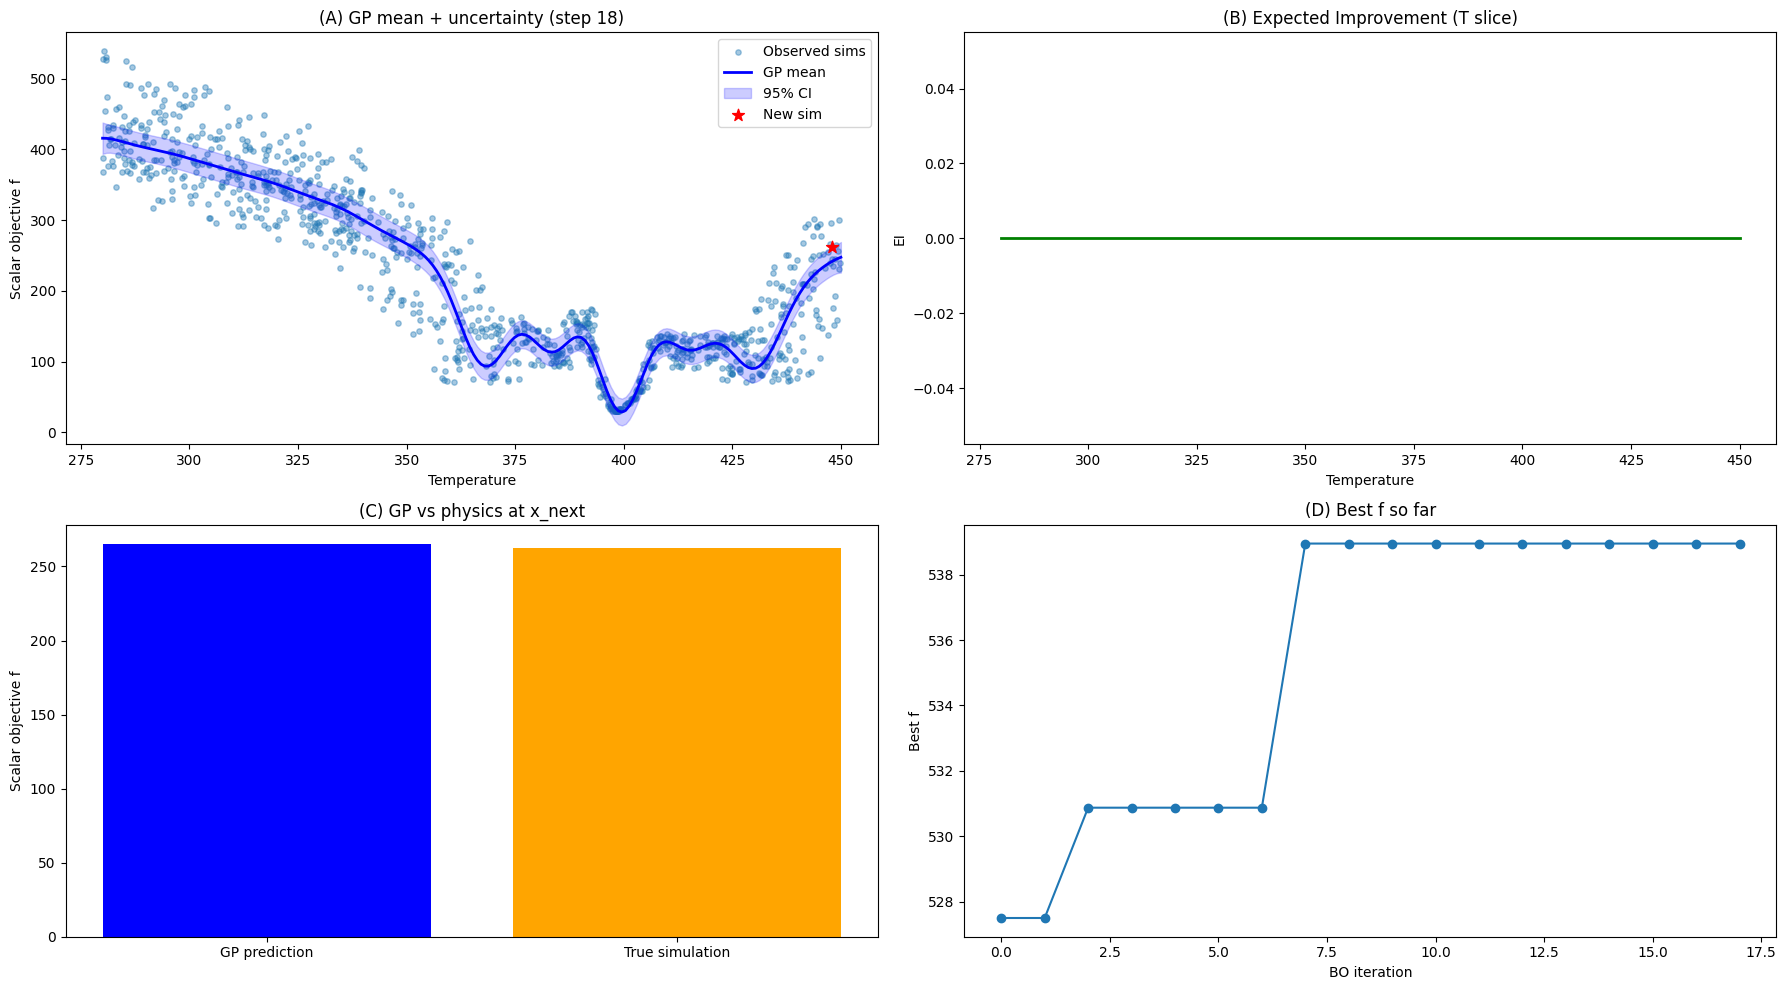


Step 18/30
x_next: [4.48045945e+02 2.31286938e-02 1.43820438e+00]
y_next: [ -90.43000468   93.05006312  201.7724417  -203.78480284  431.56291768
   -1.16000227]
new scalar f: 262.3064903997032


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 488.44it/s]


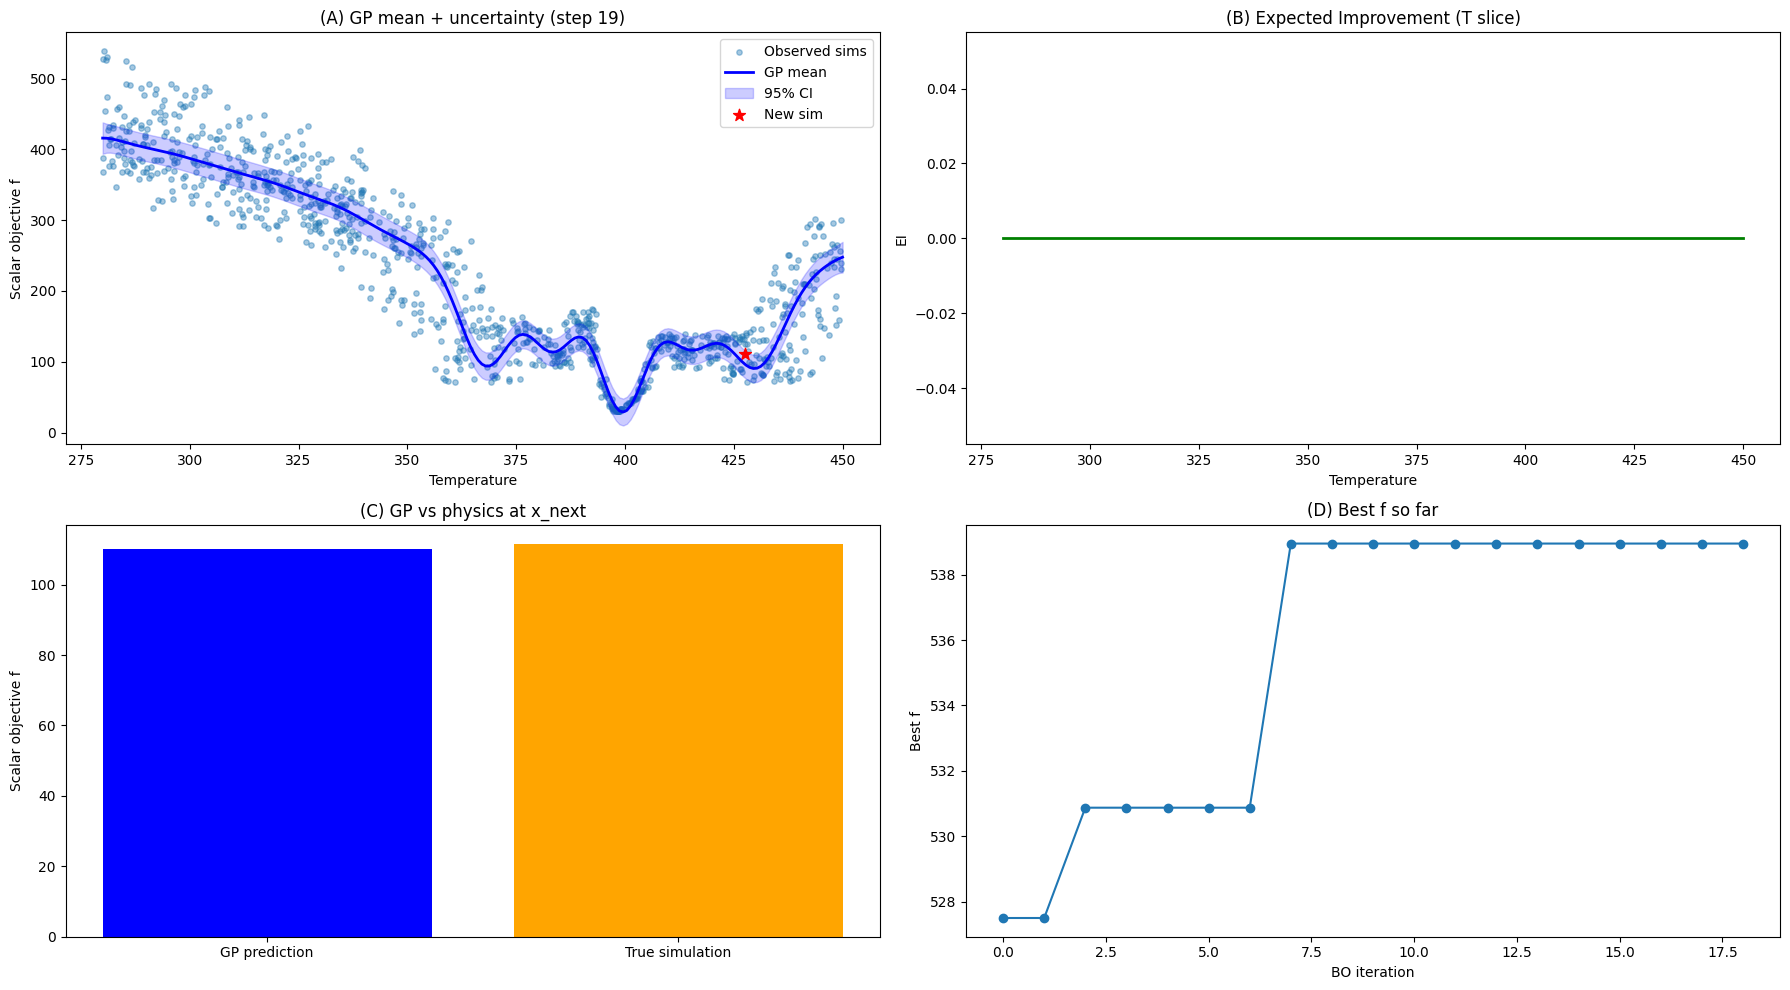


Step 19/30
x_next: [4.27619215e+02 1.76356287e-02 8.99715188e-01]
y_next: [-145.70858683  147.61064818  201.90277315 -203.06031444   75.19341439
   -0.58166006]
new scalar f: 111.40203128453875


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 488.77it/s]


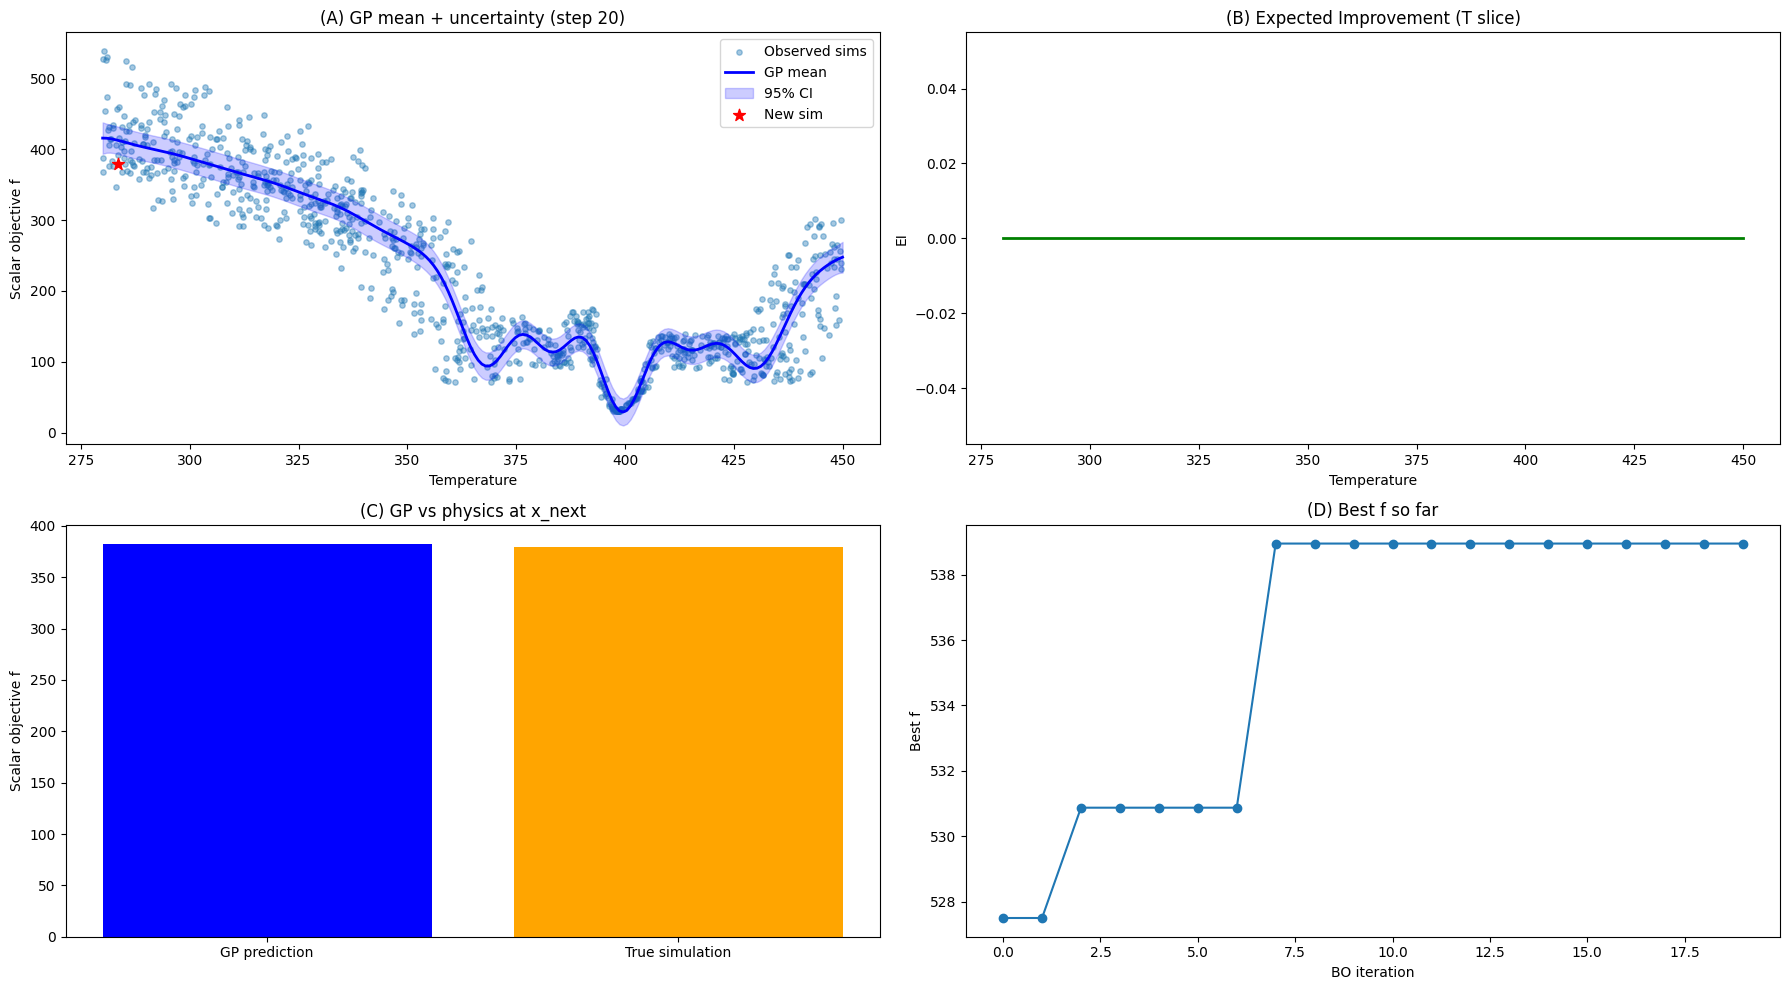


Step 20/30
x_next: [2.83559880e+02 1.40011849e-02 1.14924075e+00]
y_next: [ -79.76452517   78.53992837 -278.97384217  282.0213607   680.67962011
    1.78803142]
new scalar f: 379.6097742401712


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 459.10it/s]


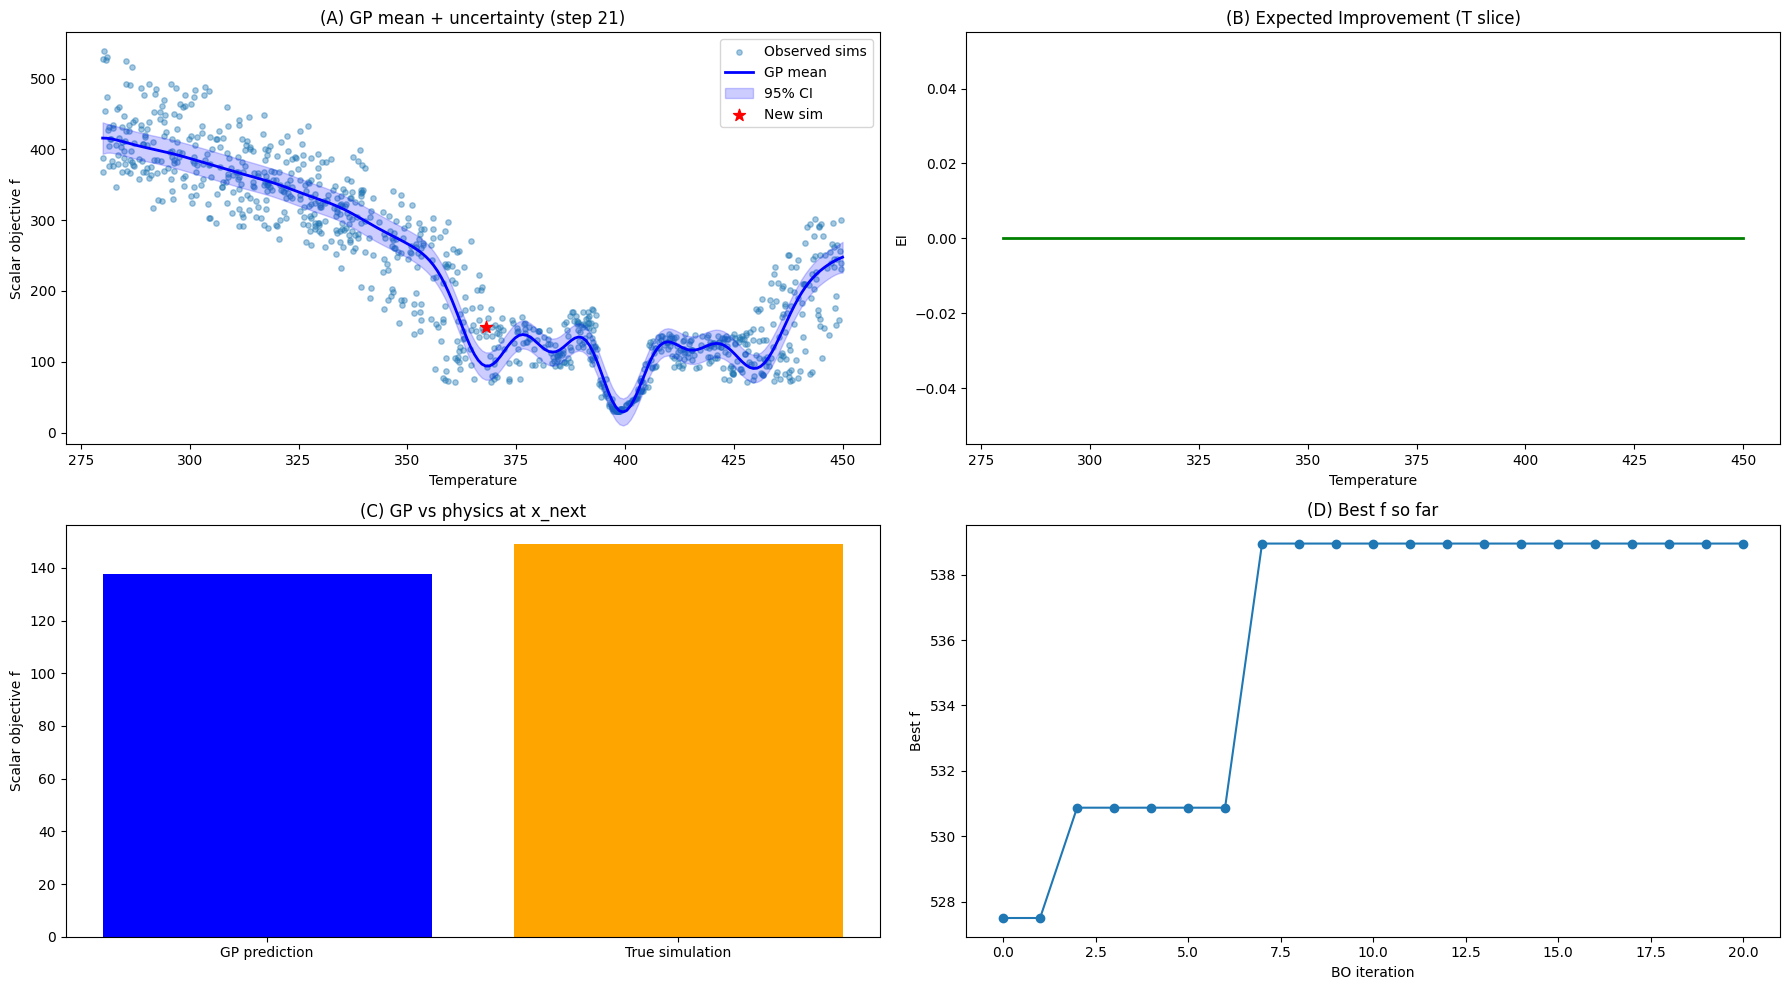


Step 21/30
x_next: [3.68142641e+02 2.17592313e-02 1.60574245e+00]
y_next: [-129.24216465  128.19556803 -181.44872417  182.62181231  169.60761922
    0.61269266]
new scalar f: 148.9015936262629


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 475.10it/s]


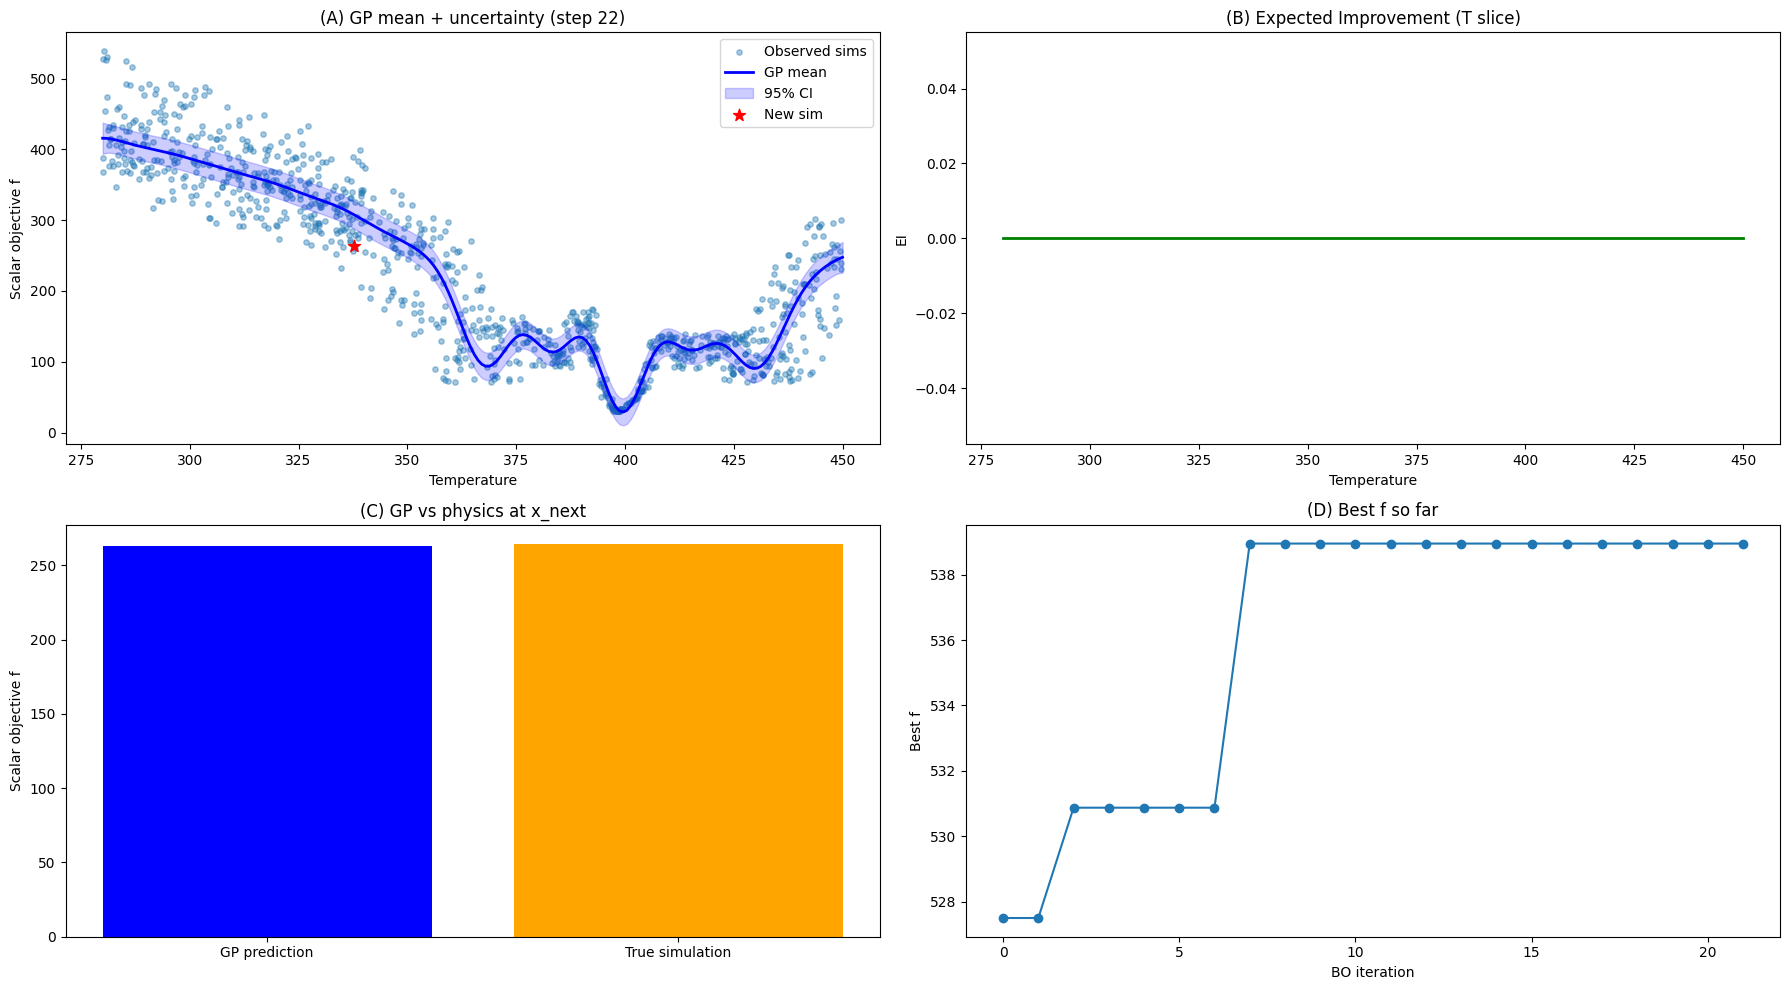


Step 22/30
x_next: [3.37737282e+02 1.59046412e-02 1.41382466e+00]
y_next: [-105.81927581  104.67711    -216.03505406  217.77427981  423.36737179
    0.9614831 ]
new scalar f: 264.0222408977836


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 469.92it/s]


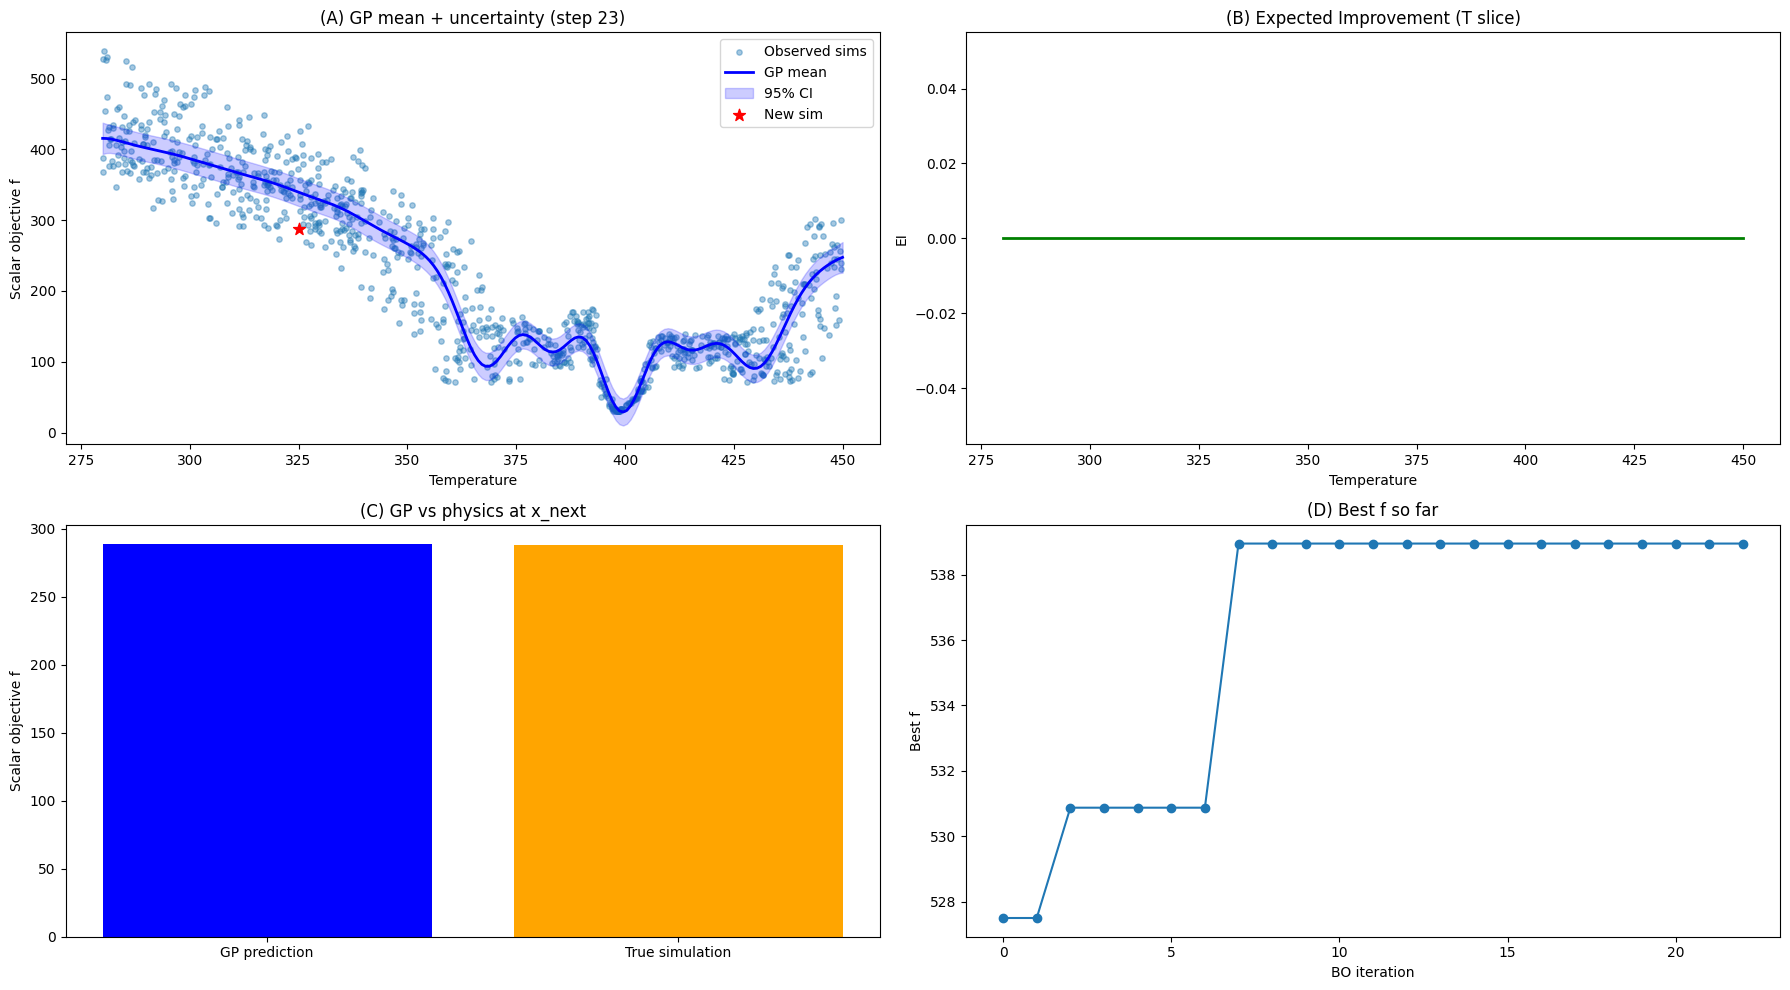


Step 23/30
x_next: [3.25120357e+02 1.54582525e-02 1.45701405e+00]
y_next: [ -95.69607988   94.55112461 -223.25407936  225.23166969  481.44862609
    1.11609573]
new scalar f: 287.99987535243184


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 438.94it/s]


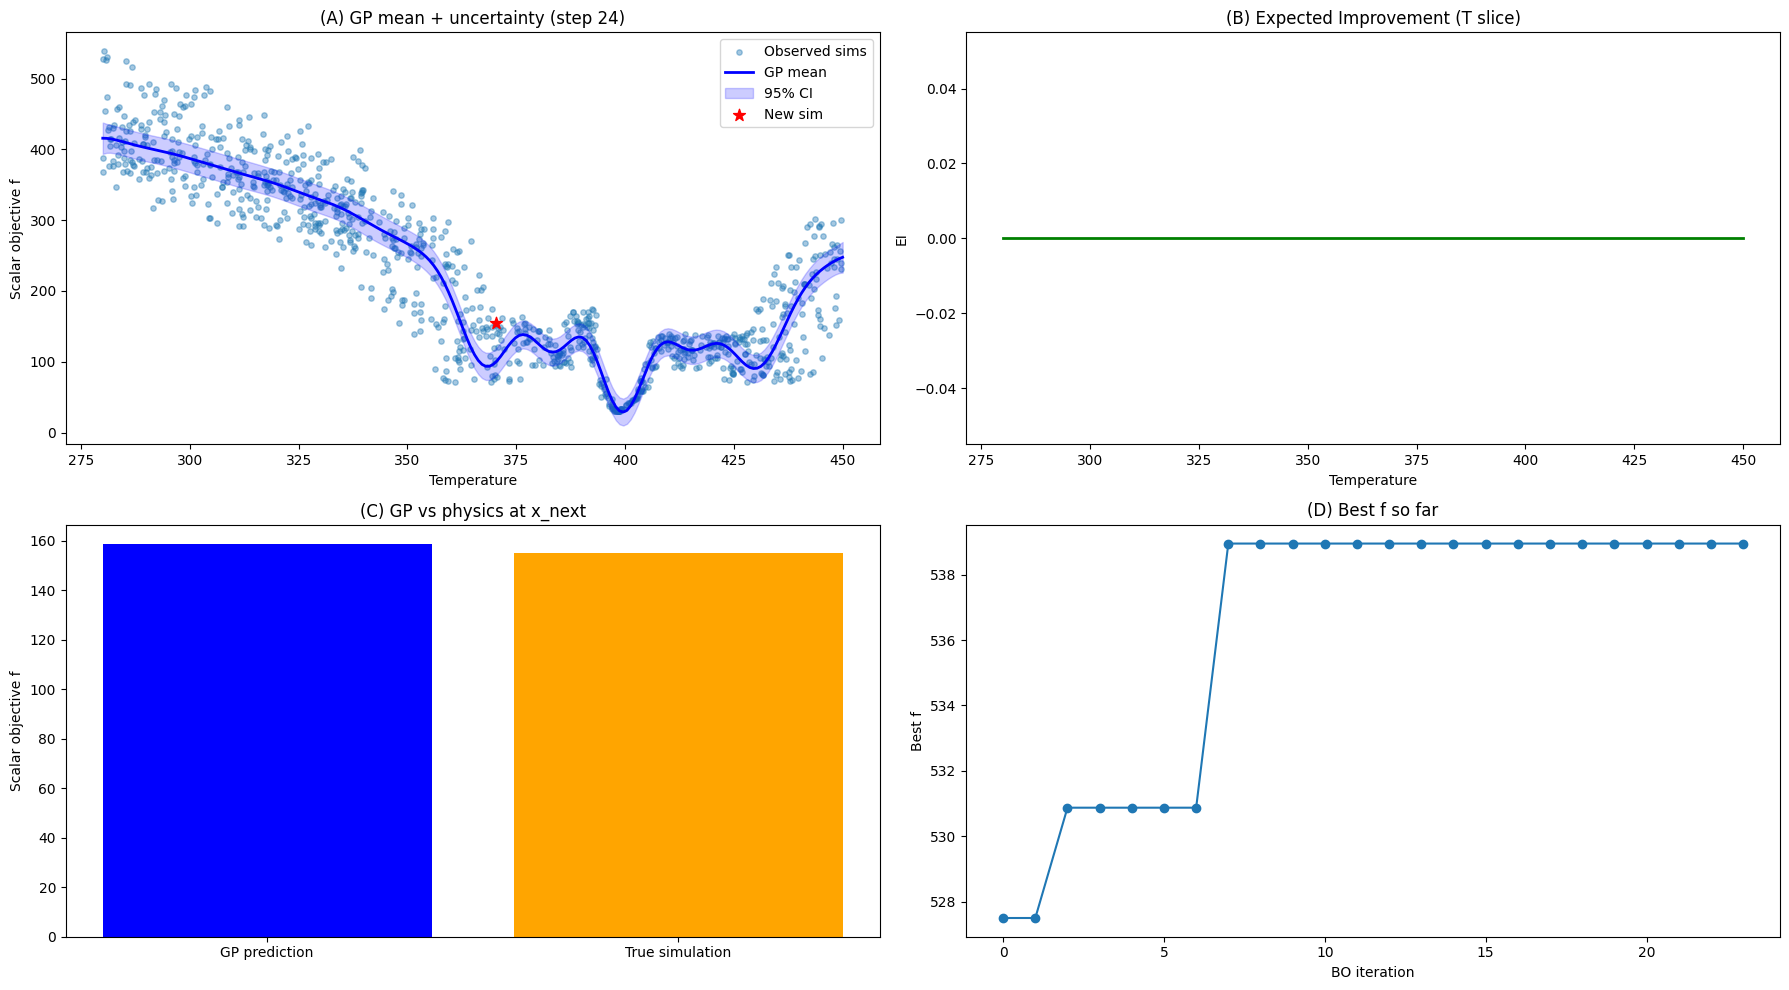


Step 24/30
x_next: [3.70385090e+02 2.28112653e-02 1.04199080e+00]
y_next: [-129.26015578  128.24737381 -223.43055819  224.85221067  182.2255595
    0.73900582]
new scalar f: 155.2364666562109


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 464.05it/s]


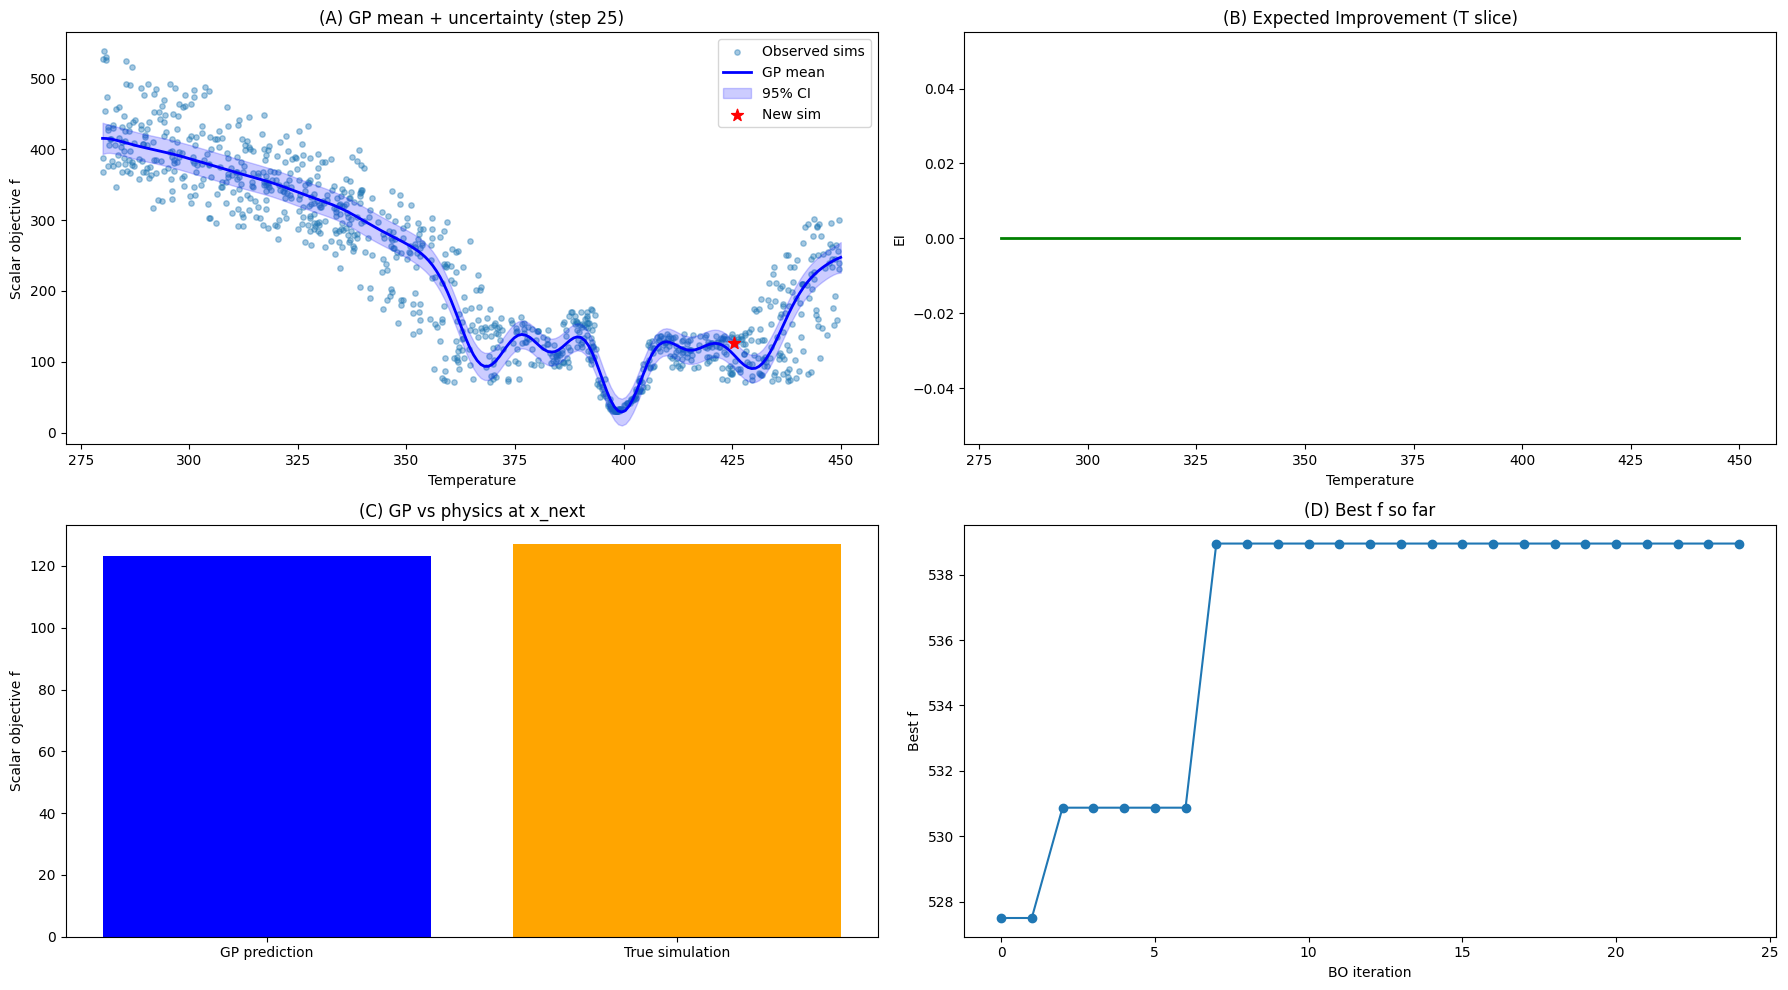


Step 25/30
x_next: [4.25468827e+02 1.62907790e-02 1.51143076e+00]
y_next: [-156.56278926  158.23847634  147.53404353 -148.28557967   95.67883773
   -0.36166769]
new scalar f: 126.9586570313595


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 495.83it/s]


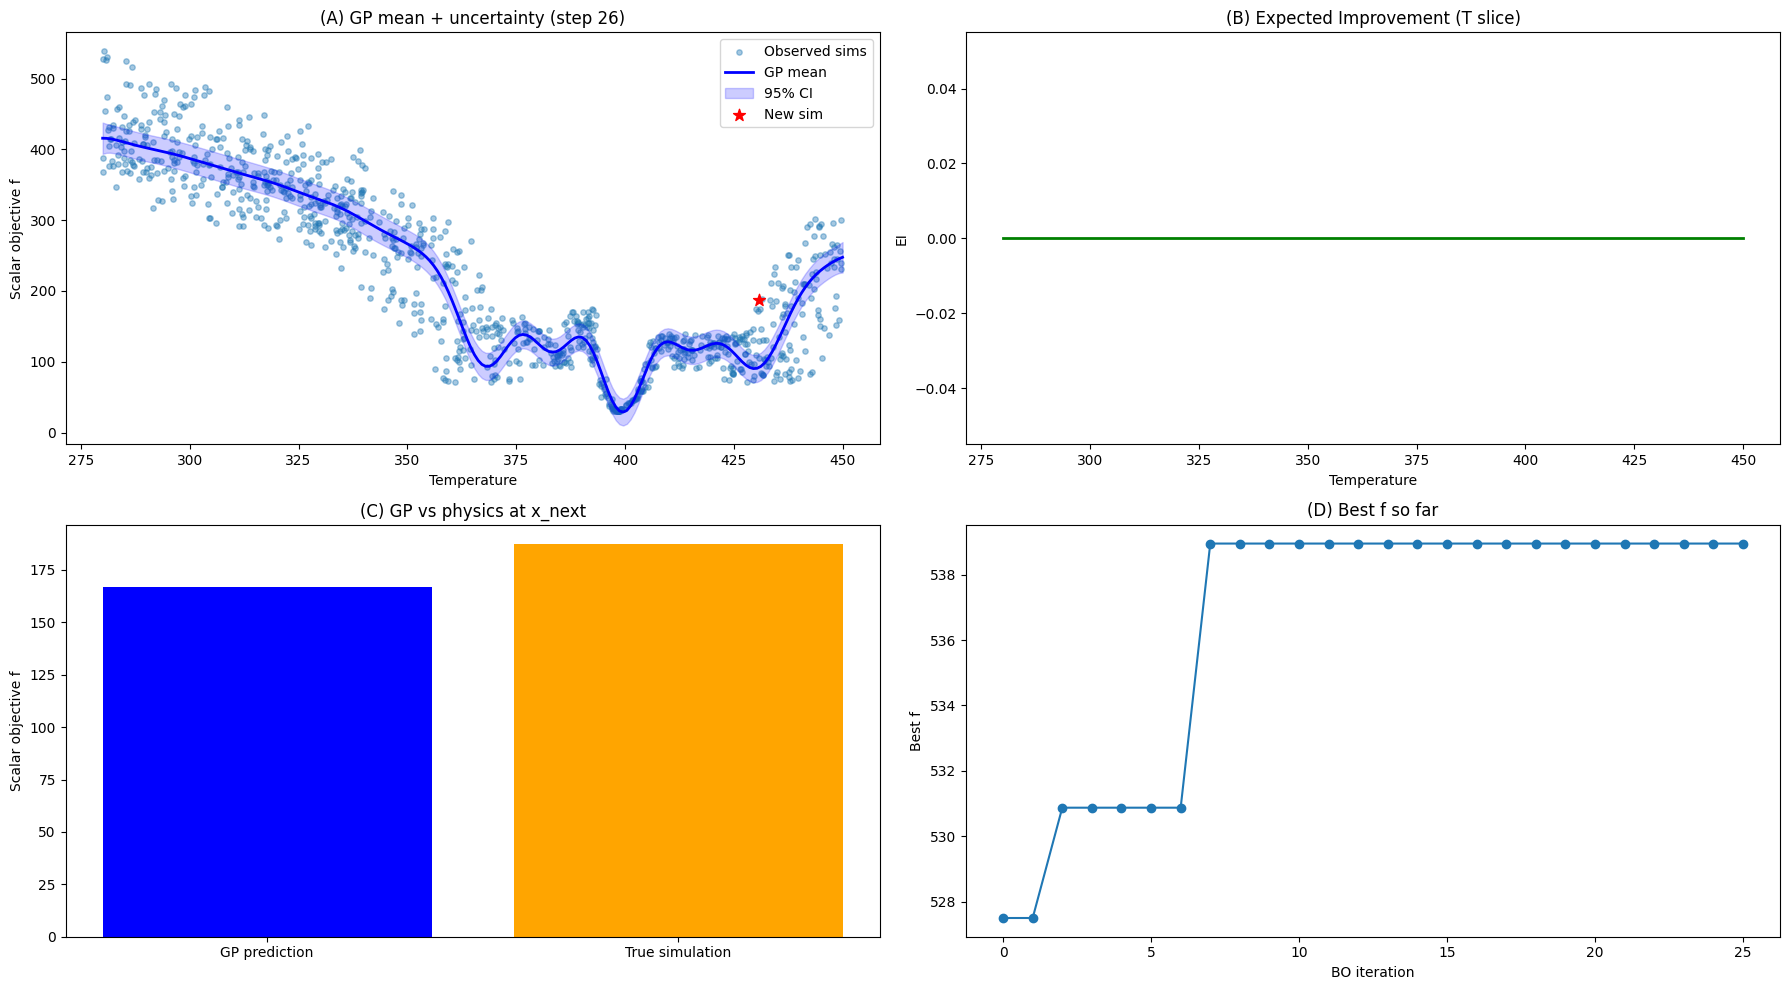


Step 26/30
x_next: [4.30791155e+02 2.30911336e-02 9.92742132e-01]
y_next: [-120.20918533  122.51122471  214.82742468 -216.41741378  251.84369606
   -0.86067724]
new scalar f: 187.17746038169145


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 475.47it/s]


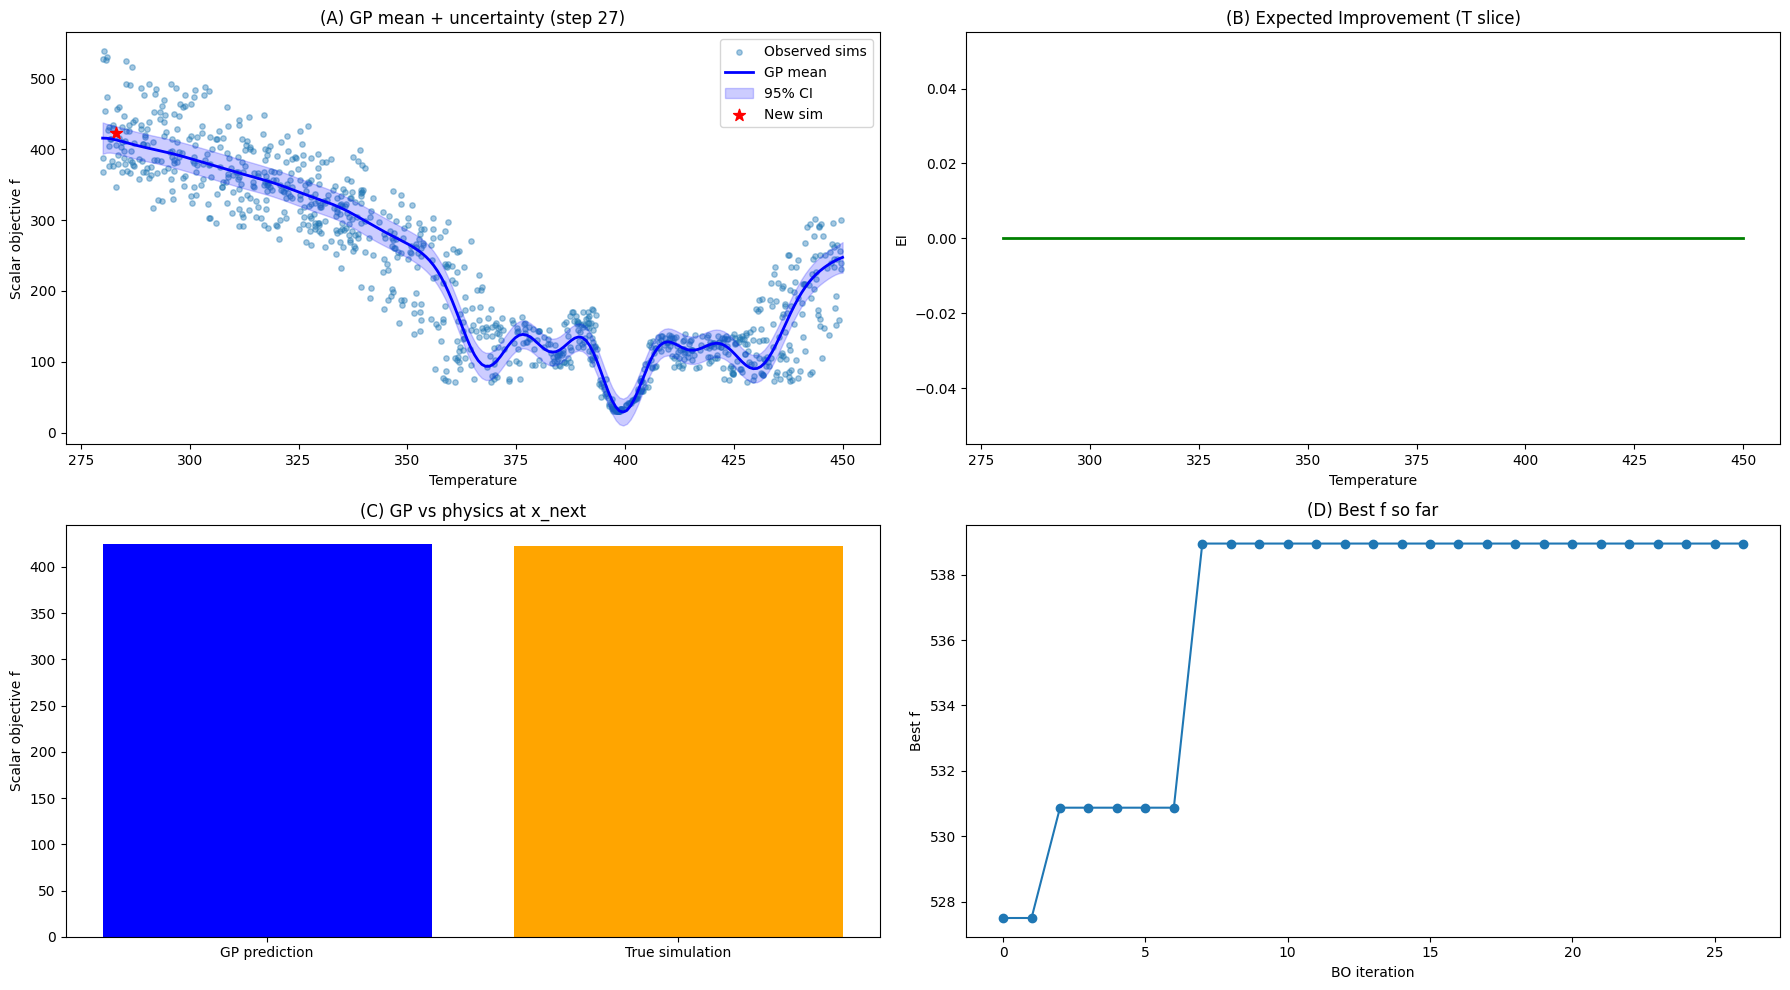


Step 27/30
x_next: [2.82961778e+02 1.75239818e-02 1.12681717e+00]
y_next: [ -68.77202342   67.56312817 -301.89255921  305.68896056  778.1496159
    2.27731854]
new scalar f: 422.8563720332417


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 481.32it/s]


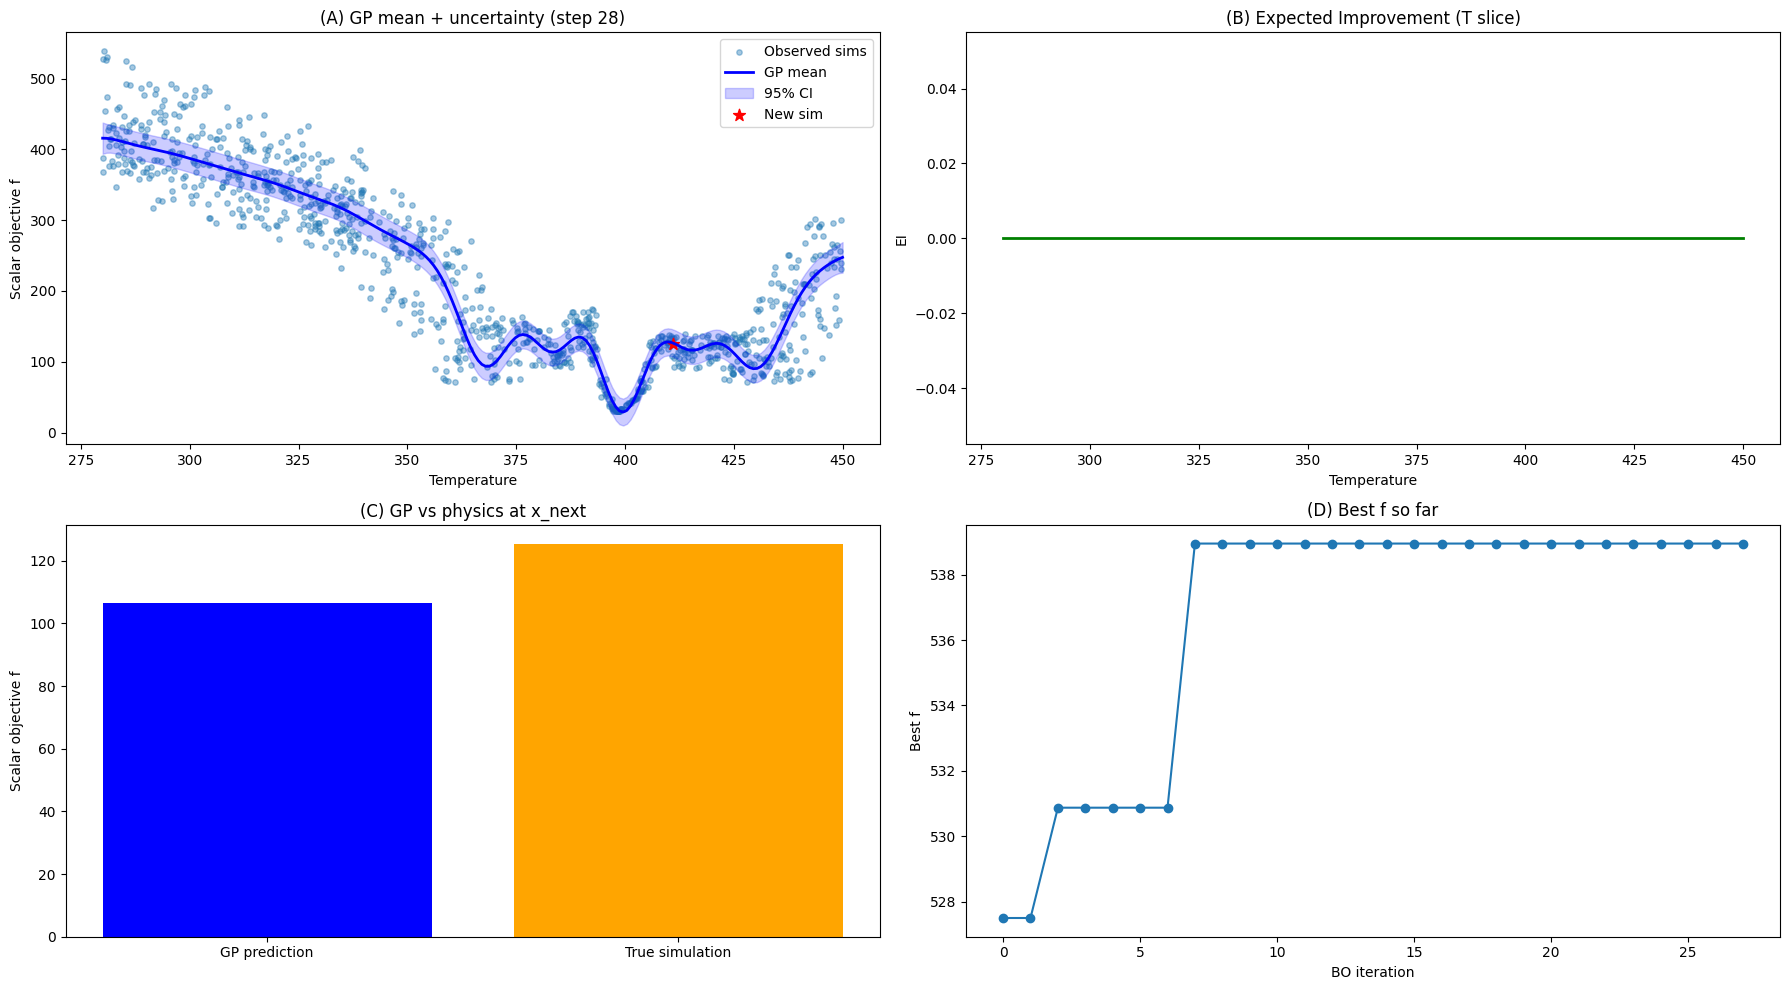


Step 28/30
x_next: [4.11017343e+02 1.94693853e-02 8.78492109e-01]
y_next: [-186.47578372  184.54758292  115.72059659 -120.06559998   65.8101605
   -0.22564775]
new scalar f: 125.178871712139


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 487.33it/s]


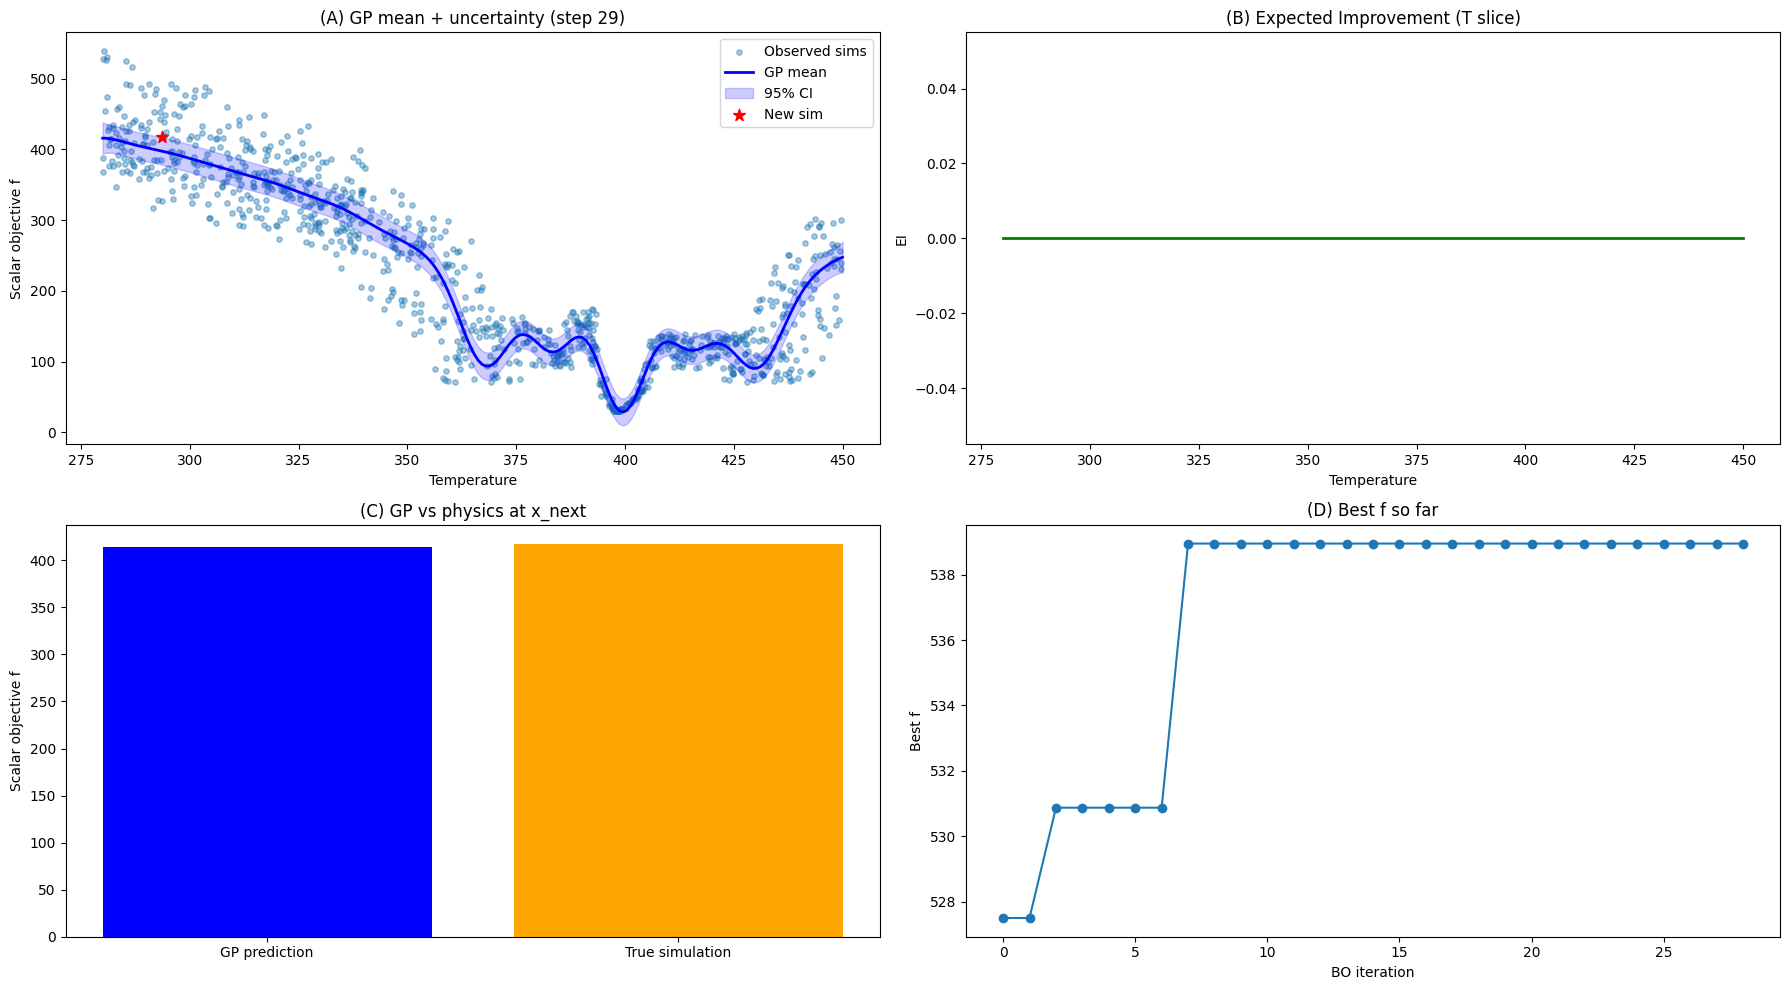


Step 29/30
x_next: [2.93715115e+02 2.36022839e-02 1.39077095e+00]
y_next: [ -63.10981121   61.80611676 -288.58728281  292.69503302  771.84971115
    2.50775758]
new scalar f: 416.8279139523439


/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/kbarakat/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__length_scale is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


---Performing simulation---


100%|██████████| 398/398 [00:00<00:00, 498.10it/s]


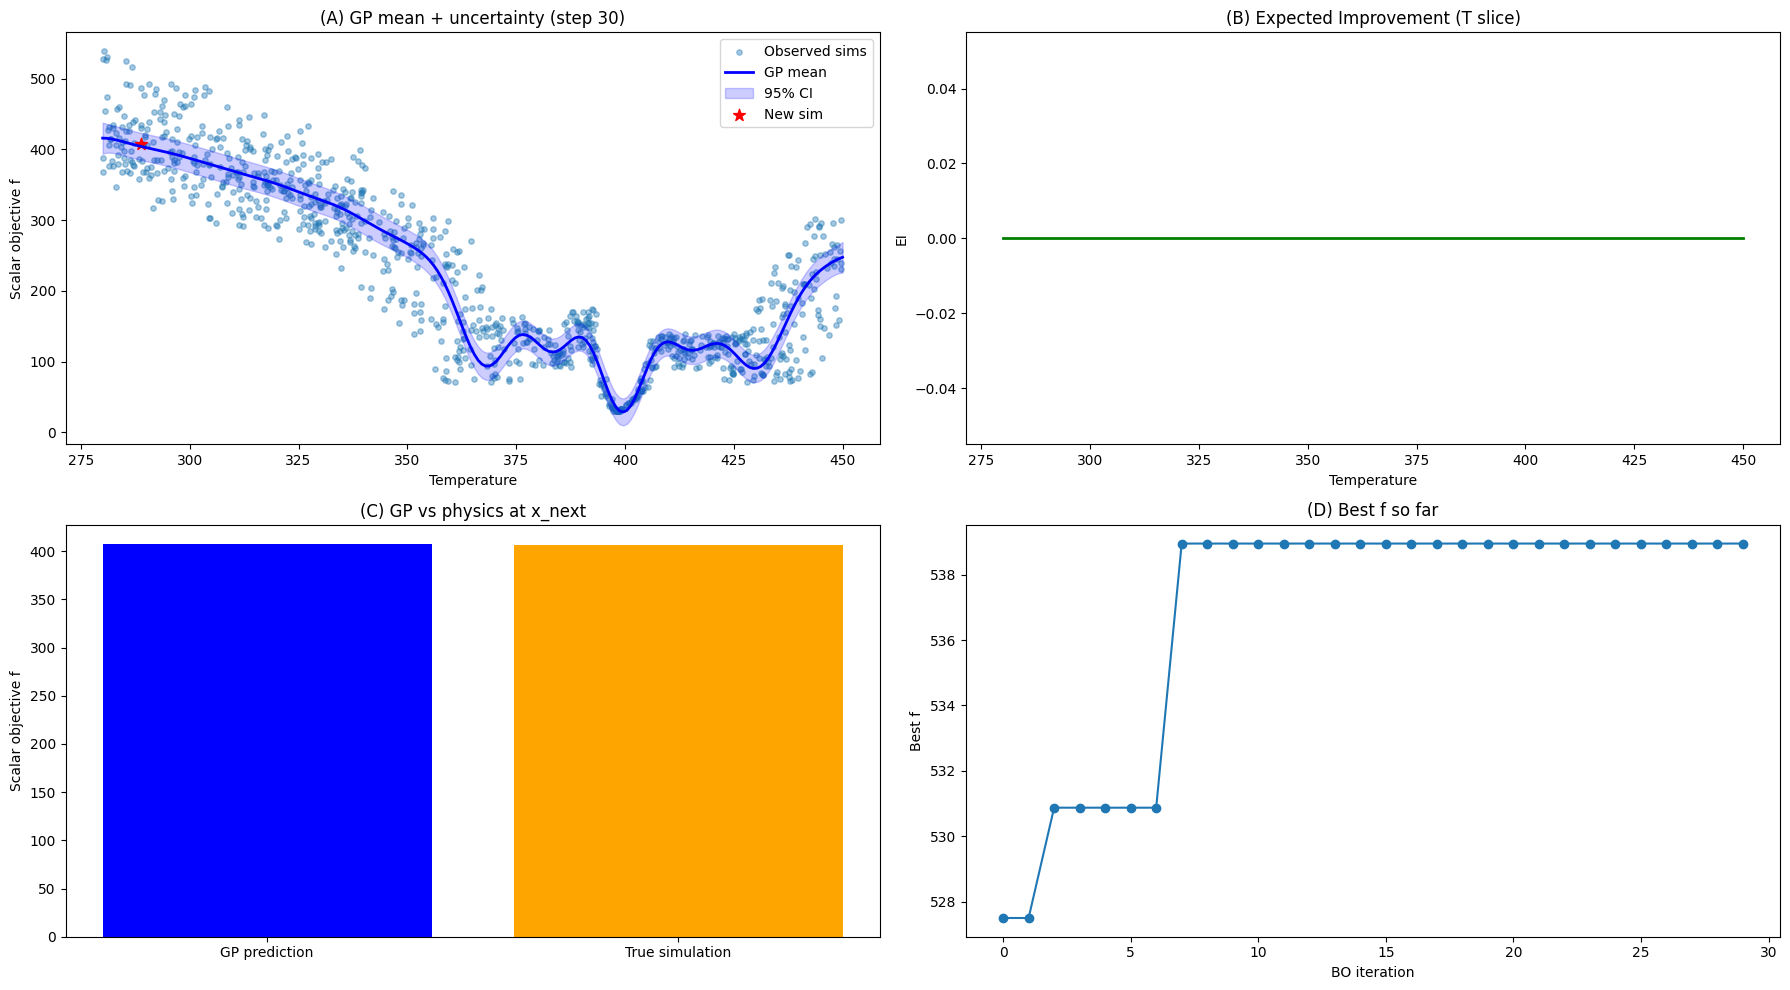


Step 30/30
x_next: [2.88899636e+02 1.68305239e-02 1.12941988e+00]
y_next: [ -74.28183961   73.0228335  -293.28876659  296.77354351  740.84455244
    2.07245615]
new scalar f: 406.9336929709332


In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

# Don't let under/overflow crash things
np.seterr(all='ignore')

# ---------------------------------------------------
# 1. Helper: scalarize 2D objective -> 1D
# ---------------------------------------------------
def scalarize(obj_2d, w1=0.5, w2=0.5):
    """
    obj_2d: array (N, 2) with [loop_area, Ec_plus]
    returns: array (N,)
    """
    obj_2d = np.asarray(obj_2d)
    if obj_2d.ndim == 1:
        obj_2d = obj_2d.reshape(1, -1)
    return w1 * obj_2d[:, 0] + w2 * obj_2d[:, 1]

# ---------------------------------------------------
# 2. Helper: evaluate_theta using your simulator
# ---------------------------------------------------
def evaluate_theta(theta):
    """
    theta: [temp, alpha1, alpha2]
    returns: [Ec_minus, Ec_plus, Pr_minus, Pr_plus, loop_area, slope_at_origin]
    """
    temp, a1, a2 = theta
    feats = run_uniaxial_sim(temp, a1, a2)
    return np.array([
        feats['Ec_minus'],
        feats['Ec_plus'],
        feats['Pr_minus'],
        feats['Pr_plus'],
        feats['loop_area'],
        feats['slope_at_origin']
    ], dtype=float)

# ---------------------------------------------------
# 3. Helper: numerically safe EI from (mu, sigma)
# ---------------------------------------------------
def expected_improvement_from_mu(mu, sigma, f_best, xi=0.01):
    """
    mu, sigma: arrays for the SAME candidate points
    f_best: current best scalar objective
    returns: EI for each point (same shape as mu)
    """
    mu = np.asarray(mu)
    sigma = np.asarray(sigma)

    sigma = np.maximum(sigma, 1e-12)
    imp = mu - f_best - xi

    ei = np.zeros_like(mu)

    # Only points that look better than current best matter
    mask = imp > 0
    if np.any(mask):
        Z = imp[mask] / sigma[mask]
        # Clip Z to avoid huge exp(-Z^2/2) underflows
        Z = np.clip(Z, -8.0, 8.0)
        with np.errstate(all='ignore'):
            ei[mask] = imp[mask] * norm.cdf(Z) + sigma[mask] * norm.pdf(Z)

    return ei

# ---------------------------------------------------
# 4. BO SETTINGS & INITIAL DATA
# ---------------------------------------------------
n_steps      = 30
n_candidates = 2000

# Start from your pre-generated dataset (1000 sims)
# X : (N0, 3)  -> [temp, alpha1, alpha2]
# Y : (N0, 6)  -> [Ec-, Ec+, Pr-, Pr+, loop_area, slope_at_origin]
X_bo = X.copy()
Y_bo = Y.copy()

history_best = []   # best scalar objective after each BO step
history_x    = []   # chosen parameter points

# Convenience: parameter ranges for sampling
T_min, T_max = 280, 450
a1_min, a1_max = X[:, 1].min(), X[:, 1].max()
a2_min, a2_max = X[:, 2].min(), X[:, 2].max()

# ---------------------------------------------------
# 5. FULL BO LOOP
# ---------------------------------------------------
for step in range(n_steps):

    # ---- 5.1 scalar objective from current database ----
    # using loop_area (col 4) and Ec_plus (col 1)
    obj_bo = Y_bo[:, [4, 1]]           # shape (N, 2)
    f_bo   = scalarize(obj_bo, 0.5, 0.5)
    f_best = np.max(f_bo)
    history_best.append(f_best)

    # ---- 5.2 normalize inputs ----
    X_mean = X_bo.mean(axis=0)
    X_std  = X_bo.std(axis=0)
    X_std[X_std == 0] = 1.0
    X_norm = (X_bo - X_mean) / X_std

    # ---- 5.3 GP model (bounded length scale, some noise) ----
    kernel = (
        RBF(length_scale=np.ones(3), length_scale_bounds=(0.2, 3.0)) +
        WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1.0))
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=3,
        alpha=1e-4
    )

    with np.errstate(all='ignore'):
        gp.fit(X_norm, f_bo)

    # ---- 5.4 sample candidate points in full 3D ----
    temps  = np.random.uniform(T_min, T_max, n_candidates)
    a1cand = np.random.uniform(a1_min,   a1_max, n_candidates)
    a2cand = np.random.uniform(a2_min,   a2_max, n_candidates)
    Xcand  = np.vstack([temps, a1cand, a2cand]).T
    Xcand_norm = (Xcand - X_mean) / X_std

    with np.errstate(all='ignore'):
        mu_cand, sigma_cand = gp.predict(Xcand_norm, return_std=True)

    # ---- 5.5 EI acquisition on candidates ----
    ei = expected_improvement_from_mu(mu_cand, sigma_cand, f_best, xi=0.01)
    idx = np.argmax(ei)
    x_next = Xcand[idx]
    history_x.append(x_next)

    # ---- 5.6 physics evaluation at x_next ----
    y_next = evaluate_theta(x_next)

    # ---- 5.7 update database ----
    X_bo = np.vstack([X_bo, x_next])
    Y_bo = np.vstack([Y_bo, y_next])

    # Recompute scalar objective including the new point
    obj_bo = Y_bo[:, [4, 1]]
    f_bo   = scalarize(obj_bo, 0.5, 0.5)

    # --------------------------------------------------------
    # 6. VISUALIZATION (nice 1D slice in temperature)
    # --------------------------------------------------------
    # Take a representative slice a1,a2 ~ medians of currently explored space
    a1_slice = np.median(X_bo[:, 1])
    a2_slice = np.median(X_bo[:, 2])

    T_grid = np.linspace(T_min, T_max, 200)
    X_slice = np.vstack([
        T_grid,
        a1_slice * np.ones_like(T_grid),
        a2_slice * np.ones_like(T_grid)
    ]).T
    X_slice_norm = (X_slice - X_mean) / X_std

    with np.errstate(all='ignore'):
        mu_slice, sigma_slice = gp.predict(X_slice_norm, return_std=True)

    ei_slice = expected_improvement_from_mu(mu_slice, sigma_slice, f_best, xi=0.01)

    fig = plt.figure(figsize=(18, 10))

    # (A) GP mean + uncertainty along T slice
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.scatter(X_bo[:, 0], f_bo, s=15, alpha=0.4, label="Observed sims")
    ax1.plot(T_grid, mu_slice, color='blue', lw=2, label='GP mean')
    ax1.fill_between(T_grid,
                     mu_slice - 2*sigma_slice,
                     mu_slice + 2*sigma_slice,
                     color='blue', alpha=0.2, label='95% CI')

    true_val = scalarize(y_next[[4, 1]])[0]
    ax1.scatter([x_next[0]], [true_val],
                color='red', marker='*', s=80, label='New sim')

    ax1.set_title(f"(A) GP mean + uncertainty (step {step+1})")
    ax1.set_xlabel("Temperature")
    ax1.set_ylabel("Scalar objective f")
    ax1.legend()

    # (B) EI along T slice
    ax2 = fig.add_subplot(2, 2, 2)
    ax2.plot(T_grid, ei_slice, color='green', lw=2)
    ax2.set_title("(B) Expected Improvement (T slice)")
    ax2.set_xlabel("Temperature")
    ax2.set_ylabel("EI")

    # (C) GP vs physics at chosen x_next
    ax3 = fig.add_subplot(2, 2, 3)
    pred_val = mu_cand[idx]
    ax3.bar(["GP prediction", "True simulation"],
            [pred_val, true_val],
            color=["blue", "orange"])
    ax3.set_title("(C) GP vs physics at x_next")
    ax3.set_ylabel("Scalar objective f")

    # (D) Best objective trajectory
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.plot(history_best, marker='o')
    ax4.set_title("(D) Best f so far")
    ax4.set_xlabel("BO iteration")
    ax4.set_ylabel("Best f")

    plt.tight_layout()
    plt.show()

    print(f"\nStep {step+1}/{n_steps}")
    print("x_next:", x_next)
    print("y_next:", y_next)
    print("new scalar f:", true_val)
